# Optimización Industrial con Computación Evolutiva
Diplomatura de Especialización en Desarrollo de Aplicaciones con Inteligencia Artificial

## Problema 3: Asignación de Vuelos a Gates en un aeropuerto

Solución integral: algoritmo genético monoobjetivo, experimentación y NSGA-II

---

### Problema

Se dispone de 30 vuelos próximos a llegar y 10 Gates. Cada individuo debe resolver simultáneamente:

1. qué 10 vuelos atender, y
2. qué Gate asignar a cada vuelo seleccionado.

La representación debe respetar dos restricciones de factibilidad:

- un vuelo aparece como máximo una vez;
- un Gate aparece como máximo una vez.

La unidad heredable del cromosoma es la asignación completa `(vuelo, Gate)`.

### Objetivo monoobjetivo

La eficiencia se calcula como:

$$
\mathrm{Fitness}(x)=\sum_{i=1}^{K}\frac{P_i}{T_{i,g_i}}
$$
y se maximiza.

### Objetivos multiobjetivo

En NSGA-II se optimizan de forma separada:

- \(f_1\): maximizar el número total de pasajeros de los vuelos seleccionados;
- \(f_2\): minimizar el tiempo total de desembarque de los vuelos en los Gates asignados.

### Diseño experimental

El cuaderno incluye:

- verificación de factibilidad de operadores;
- comparación de operadores de cruzamiento con mutación deshabilitada;
- evaluación de mutaciones en los niveles de vuelos y Gates;
- múltiples tasas de mutación;
- 10 corridas independientes por configuración monoobjetivo;
- cálculo exacto del óptimo monoobjetivo de la instancia como referencia de validación;
- medición del gap al óptimo, tasa de éxito, convergencia y diversidad;
- NSGA-II con 50 individuos, 100 generaciones y 5 corridas;
- fronteras de Pareto y comparación con las soluciones monoobjetivo.


## 0. Librerías

Se utilizan `numpy`, `random`, `copy` y `matplotlib`. Los operadores genéticos, la reparación de
individuos, el algoritmo genético y NSGA-II se implementan directamente en Python.


In [ ]:
import sys
import time
import numpy as np
import random
from random import seed, randint, sample, uniform, randrange
from copy import deepcopy
import matplotlib.pyplot as plt


## 1. Representación del individuo

Un individuo representa una programación completa mediante dos listas paralelas de longitud \(K\):

```text
índice        0        1        2       ...     K-1
flights   [ F17   ,  F03   ,  F25   , ... ,  F08 ]
gates     [ G4    ,  G9    ,  G1    , ... ,  G6  ]
```

La posición `i` representa la asignación `(flights[i], gates[i])`.

Un individuo es factible cuando:

- todos los vuelos son distintos;
- todos los Gates son distintos.

La clase `Individual` se utiliza como configuración comparativa en los experimentos solicitados.


In [ ]:
# Clase que implementa el individuo y los operadores convencionales de comparacion
class Individual(object):

    # El constructor recibe la lista de vuelos que representa el individuo y los gates asignados, asi como el pool de flights y gates
    def __init__(self, flights, gates, flights_pool, gates_pool):
        self.flights = flights[:]
        self.gates = gates[:]
        self.flights_pool = flights_pool
        self.gates_pool = gates_pool
        self.fitness = -1  # -1 indica que el individuo no ha sido evaluado

    def crossover_onepoint(self, other):
        "Retorna dos nuevos individuos del cruzamiento de un punto entre individuos self y other "
        c = randrange(len(self.gates))  # escoge aleatoriamento una posicion en la lista gates
        ind1 = self.__class__(self.flights, self.gates[:c] + other.gates[c:], self.flights_pool, self.gates_pool)
        ind2 = self.__class__(self.flights, other.gates[:c] + self.gates[c:], self.flights_pool, self.gates_pool)
        return [ind1, ind2]

    def crossover_uniform(self, other):
        "Retorna dos nuevos individuos del cruzamiento uniforme entre self y other "
        gates_ind1 = []
        gates_ind2 = []

        for i in range(len(self.gates)):
            if uniform(0, 1) < 0.5:
                gates_ind1.append(self.gates[i])
                gates_ind2.append(other.gates[i])
            else:
                gates_ind1.append(other.gates[i])
                gates_ind2.append(self.gates[i])
        ind1 = self.__class__(self.flights, gates_ind1, self.flights_pool, self.gates_pool)
        ind2 = self.__class__(self.flights, gates_ind2, self.flights_pool, self.gates_pool)
        return [ind1, ind2]

    def mutate_position(self):
        "Cambia aleatoriamente el Gate asignado a un Flight."
        mutated_gates = deepcopy(self.gates)
        indexGate = randrange(0, len(self.gates))  # escoje el indice del elemento de gates que sera mutado
        newGate = self.gates_pool[randrange(0, len(self.gates_pool))]
        mutated_gates[indexGate] = newGate
        return self.__class__(self.flights, mutated_gates, self.flights_pool, self.gates_pool)


### 1.1 Clases `Gate`, `Sleeve`, `Zone` y `Flight`

- Gate: lugar de parqueo.
- Sleeve: los pasajeros desembarcan caminando por una manga.
- Zone: los pasajeros son trasladados en bus.
- Flight: contiene capacidad, pasajeros, tiempos operativos, longitud de alas y ventana de llegada/salida.


In [ ]:
class Gate(object):
    def __init__(self, identifier, x, y, z):
        self.identifier = identifier   # identificador del Gate
        self.distance = x              # en el caso de Sleeve esto almacena la longitud de manga. En el caso de zonas es la distancia a una puerta del aeropuerto
        self.potential_of_speed = y    # en el caso de Sleeve esto almacena la velocidad de pasajeros en manga. En el caso de zona almacena la velocidad del bus
        self.number_of_persons_every_10m = z   # en el caso de Sleeve esto almacena el numero de personas cada 10 metros. En el cazo de zona es la capacidad del bus

    def __hash__(self):
        return self.identifier


class Sleeve(Gate):
    def __init__(self, identifier, length_of_sleeve, speed_of_passengers_on_sleeve, number_of_passengers_every_10m):
        super().__init__(identifier, length_of_sleeve, speed_of_passengers_on_sleeve, number_of_passengers_every_10m)


class Zone(Gate):
    def __init__(self, identifier, distance_zone_door, speed_bus, capacity_of_bus):
        super().__init__(identifier, distance_zone_door, speed_bus, capacity_of_bus)


class Flight(object):
    def __init__(self, identifier, maximum_capacity, number_of_passengers, parking_time, length_wings, inspection_time, landing_time_on_stairs, arriving_time, leaving_time):
        self.identifier = identifier  # identificador de vuelo
        self.maximum_capacity = maximum_capacity  # maxima capacidad del vuelo
        self.number_of_passengers = number_of_passengers  # numero de pasajeros
        self.parking_time = parking_time   # tiempo de parqueo
        self.length_wings = length_wings   # longitud de las alas
        self.inspection_time = inspection_time  # tiempo de inspeccion
        self.landing_time_on_stairs = landing_time_on_stairs
        self.arriving_time = arriving_time   # tiempo de llegada al aeropuerto
        self.leaving_time = leaving_time   # tiempo de partida del aeropuerto

    def __hash__(self):
        return self.identifier


## 2. Generación de la instancia

Se generan 30 vuelos y 10 Gates con atributos aleatorios dentro de los rangos definidos por el problema.
La semilla de la instancia queda fija para que todas las configuraciones sean comparables.


In [ ]:
# Genera una lista de Gates
def generate_list_of_gates(number_of_gates, max_length_of_sleeve=20, max_speed_of_passengers_on_sleeve=3, max_number_of_passengers_every_10m=12, max_distance_zone_door=50, max_speed_bus=15, max_capacity_of_bus=200):
  list_of_gates = list()

  for gate_identifier in range(number_of_gates):
    gate_type = randint(0, 1)

    if gate_type == 0:   # caso manga
      distance = randint(1, max_length_of_sleeve)
      potential_of_speed = randint(1, max_speed_of_passengers_on_sleeve)
      number_of_persons_every_10m = randint(1, max_number_of_passengers_every_10m)

      gate = Sleeve(gate_identifier, distance, potential_of_speed, number_of_persons_every_10m)

    else:    # caso zone
      distance = randint(1, max_distance_zone_door)
      potential_of_speed = randint(1, max_speed_bus)
      number_of_persons_every_10m = randint(1, max_capacity_of_bus)

      gate = Zone(gate_identifier, distance, potential_of_speed, number_of_persons_every_10m)

    list_of_gates.append(gate)

  return list_of_gates


# Genera una lista de Flights
def generate_list_of_flights(number_of_flights, max_maximum_capacity=100, max_number_of_passengers_factor=0.8, max_parking_time=30, max_length_wings=25, max_inspection_time=180, max_landing_time_on_stairs=60, max_arriving_time=200, max_leaving_time=1000):
  list_of_flights = list()

  max_number_of_passengers = int(round(max_number_of_passengers_factor * max_maximum_capacity))

  for flight_identifier in range(number_of_flights):
    maximum_capacity = randint(max_number_of_passengers, max_maximum_capacity)
    number_of_passengers = randint(1, max_number_of_passengers)
    parking_time = randint(1, max_parking_time)
    length_wings = randint(1, max_length_wings)
    inspection_time = randint(1, max_inspection_time)
    landing_time_on_stairs = randint(1, max_landing_time_on_stairs)
    arriving_time = randint(1, max_arriving_time)
    leaving_time = randint(max_arriving_time + 1, max_leaving_time)

    flight = Flight(flight_identifier, maximum_capacity, number_of_passengers, parking_time, length_wings, inspection_time, landing_time_on_stairs, arriving_time, leaving_time)

    list_of_flights.append(flight)

  return list_of_flights


### 2.1 Funciones auxiliares

- `process_desirability(flight)`: pasajeros divididos entre el tiempo que el vuelo permanece en el aeropuerto.
- `process_flow(gate)`: flujo estimado de personas que puede procesar el Gate.


In [ ]:
# Funcion para ordenar vuelos por su grado de deseabilidad  ( nro_pasajeros/tiempo_en_aeropuerto )
def process_desirability(n):
  return n.number_of_passengers / (n.leaving_time - n.arriving_time)

# Funcion para ordenar Gates por su capacidad de flujo de personas
def process_flow(n):
  return n.number_of_persons_every_10m * n.potential_of_speed * 10 / n.distance


In [ ]:
def generate_problem_instance(number_of_flights=30, number_of_gates=10, instance_seed=0):
  """Genera la instancia pedida en el enunciado: 30 vuelos y 10 gates.

  Retorna (list_of_flights, list_of_gates, flights_to_assign), donde flights_to_assign = min(#vuelos, #gates)
  es la cantidad de asignaciones de cada individuo (largo del cromosoma).
  La semilla fija garantiza que TODOS los experimentos de este notebook usen exactamente la misma instancia.
  """
  seed(instance_seed)
  np.random.seed(instance_seed)

  list_of_gates = generate_list_of_gates(number_of_gates)
  list_of_flights = generate_list_of_flights(number_of_flights)

  # el numero de vuelos que el algoritmo puede programar no puede exceder el numero de gates disponibles
  flights_to_assign = number_of_flights if number_of_flights <= number_of_gates else number_of_gates

  # ordena los vuelos por su deseabilidad y los gates por su capacidad de flujo de personas
  list_of_flights = sorted(list_of_flights, key=process_desirability, reverse=True)
  list_of_gates = sorted(list_of_gates, key=process_flow, reverse=True)

  return list_of_flights, list_of_gates, flights_to_assign


## 3. Evaluación: tiempo de desembarque y fitness

El tiempo de desembarque se calcula según el tipo de Gate y los atributos del vuelo.

El objetivo monoobjetivo es:

\[
Fitness(x)=\sum_{i=1}^{K}\frac{Pasajeros_i}{TiempoDesembarque_i}
\]

Por tanto, un fitness mayor representa una programación más eficiente.


In [ ]:
def disembarkation_time(flight, gate):
  """Tiempo que toma desembarcar totalmente a los pasajeros de un vuelo en el gate dado.

  Formula utilizada para evaluar la eficiencia monoobjetivo:
   - Sleeve: los pasajeros recorren a pie la manga (mas la envergadura del ala) al flujo del gate.
   - Zone  : los pasajeros bajan por escaleras y un bus los traslada hasta la puerta.
  `grace_time` es un 5% de holgura operativa.
  """
  grace_time = 5/100
  number_of_passengers = flight.number_of_passengers

  if isinstance(gate, Sleeve):  # si el gate es de tipo Manga
    return ( (number_of_passengers * (gate.distance + flight.length_wings) / process_flow(gate)) + flight.parking_time + flight.inspection_time ) * (1 + grace_time)
  else:  # si el gate es de tipo Zona
    return ( (number_of_passengers * gate.distance / process_flow(gate)) + flight.parking_time + (flight.landing_time_on_stairs * number_of_passengers / flight.maximum_capacity) + flight.inspection_time ) * (1 + grace_time)


# Evalua un individuo representado por sus listas:  flights, gates
def fitness(flights, gates):
  cumulative_efficiency = 0
  for flight, gate in zip(flights, gates):
    # la eficiencia de una asignacion flight-gate es la cantidad de pasajeros desembarcados por unidad de tiempo
    cumulative_efficiency += flight.number_of_passengers / disembarkation_time(flight, gate)
  return cumulative_efficiency


# Evaluar la poblacion con la funcion fitness
def evaluate_population(population, fitness_fn):
  """ Evalua una poblacion de individuos con la funcion de fitness pasada """
  population_size = len(population)
  for i in range(population_size):
    if population[i].fitness == -1:    # Evalua solo si el individuo no esta evaluado
      population[i].fitness = fitness_fn(population[i].flights, population[i].gates)


### 3.1 Verificacion de factibilidad

Necesitamos poder auditar cuantos individuos violan las restricciones. Un individuo es factible si:

1. no repite vuelos (un avion no puede estar en dos gates), y
2. no repite gates (un gate no puede recibir dos aviones).

`count_duplicated_gates` cuenta cuantas asignaciones sobran por gates repetidos: vale 0 en un individuo
factible y `K - 1` en el peor caso (todas las asignaciones al mismo gate).


In [ ]:
def count_duplicated_flights(ind):
  "Numero de asignaciones que repiten un vuelo ya usado (0 si el individuo es factible)"
  return len(ind.flights) - len(set(f.identifier for f in ind.flights))


def count_duplicated_gates(ind):
  "Numero de asignaciones que repiten un gate ya usado (0 si el individuo es factible)"
  return len(ind.gates) - len(set(g.identifier for g in ind.gates))


def is_valid(ind):
  "True si el individuo representa vuelos diferentes y gates diferentes"
  return count_duplicated_flights(ind) == 0 and count_duplicated_gates(ind) == 0


def population_validity_rate(population):
  "Fraccion de individuos factibles en la poblacion"
  return sum(1 for ind in population if is_valid(ind)) / len(population)


## 4. Operadores genéticos factibles

### 4.1 Unidad heredable: `(vuelo, Gate)`

El cromosoma se interpreta como una secuencia de asignaciones completas:

```text
(F17,G4) (F03,G9) (F25,G1) (F08,G6) ...
```

Los cruzamientos trabajan sobre estos pares y después aplican reparación para garantizar:

\[
|\{flights\}|=K,\qquad |\{gates\}|=K
\]

### 4.2 Reparación

La reparación sigue tres pasos:

1. conservar pares heredados que no generan conflicto;
2. intentar la asignación correspondiente del otro progenitor;
3. completar posiciones pendientes con vuelos y Gates libres.

### 4.3 Mutación

Se implementan cuatro alternativas:

- `mutate_flight`: cambia qué vuelo se atiende;
- `mutate_gate`: cambia dónde se atiende;
- `mutate_flight_and_gate`: modifica ambos niveles en el mismo evento;
- `mutate_flight_or_gate`: en cada evento modifica uno de los dos niveles al azar.

`mutate_flight_or_gate` permite explorar vuelos y Gates durante la evolución sin alterar obligatoriamente
las dos partes de una asignación en el mismo paso.


In [ ]:
class IndividualGA(Individual):
    """Individuo con operadores que garantizan individuos validos (vuelos distintos y gates distintos).

    Hereda de Individual: mantiene el mismo cromosoma (listas paralelas flights / gates) y los operadores
    originales, y agrega cruzamiento por asignaciones con reparacion, y mutacion en niveles de flight y gate.
    """

    # ------------------------------------------------------------------ utilitarios internos
    def assignments(self):
        "Retorna el cromosoma leido como lista de asignaciones (flight, gate)"
        return list(zip(self.flights, self.gates))

    def build_from_assignments(self, assignments):
        "Construye un nuevo individuo (del mismo tipo que self) a partir de una lista de asignaciones"
        flights = [assignment[0] for assignment in assignments]
        gates = [assignment[1] for assignment in assignments]
        return self.__class__(flights, gates, self.flights_pool, self.gates_pool)

    def free_flights(self, used_flight_ids):
        "Vuelos del pool que aun no estan programados"
        return [flight for flight in self.flights_pool if flight.identifier not in used_flight_ids]

    def free_gates(self, used_gate_ids):
        "Gates del pool que aun no estan ocupados"
        return [gate for gate in self.gates_pool if gate.identifier not in used_gate_ids]

    # ------------------------------------------------------------------ reparacion
    def repair_assignments(self, child_assignments, donor_assignments):
        """Repara una lista de asignaciones heredadas para que no repita vuelos ni gates.

        child_assignments: asignaciones heredadas por el hijo (pueden tener conflictos)
        donor_assignments: asignaciones del otro padre en las mismas posiciones (segunda oportunidad)
        Retorna una lista de K asignaciones factibles.
        """
        number_of_assignments = len(child_assignments)
        repaired = [None] * number_of_assignments
        used_flight_ids = set()
        used_gate_ids = set()

        # Fase 1: hereda directamente las asignaciones que no generan conflicto
        pending_positions = []
        for i in range(number_of_assignments):
            flight, gate = child_assignments[i]
            if flight.identifier not in used_flight_ids and gate.identifier not in used_gate_ids:
                repaired[i] = (flight, gate)
                used_flight_ids.add(flight.identifier)
                used_gate_ids.add(gate.identifier)
            else:
                pending_positions.append(i)

        # Fase 2: segunda oportunidad con la asignacion del otro padre en la misma posicion
        unresolved_positions = []
        for i in pending_positions:
            flight, gate = donor_assignments[i]
            if flight.identifier not in used_flight_ids and gate.identifier not in used_gate_ids:
                repaired[i] = (flight, gate)
                used_flight_ids.add(flight.identifier)
                used_gate_ids.add(gate.identifier)
            else:
                unresolved_positions.append(i)

        # Fase 3: rescate parcial - conserva la mitad libre de la asignacion y completa la otra al azar
        for i in unresolved_positions:
            flight, gate = child_assignments[i]
            if flight.identifier in used_flight_ids:
                flight = random.choice(self.free_flights(used_flight_ids))
            if gate.identifier in used_gate_ids:
                gate = random.choice(self.free_gates(used_gate_ids))
            repaired[i] = (flight, gate)
            used_flight_ids.add(flight.identifier)
            used_gate_ids.add(gate.identifier)

        return repaired

    # ------------------------------------------------------------------ cruzamiento
    def crossover_uniform_assignment(self, other):
        """Cruzamiento uniforme cuya unidad heredable es la asignacion (flight, gate) completa.

        Para cada posicion se lanza una moneda: el hijo 1 recibe el par del padre self o del padre other,
        y el hijo 2 recibe el par complementario. Luego ambos hijos se reparan.
        """
        assignments_self = self.assignments()
        assignments_other = other.assignments()

        assignments_child1 = []
        assignments_child2 = []
        for i in range(len(assignments_self)):
            if uniform(0, 1) < 0.5:
                assignments_child1.append(assignments_self[i])
                assignments_child2.append(assignments_other[i])
            else:
                assignments_child1.append(assignments_other[i])
                assignments_child2.append(assignments_self[i])

        ind1 = self.build_from_assignments(self.repair_assignments(assignments_child1, assignments_child2))
        ind2 = self.build_from_assignments(self.repair_assignments(assignments_child2, assignments_child1))
        return [ind1, ind2]

    def crossover_onepoint_assignment(self, other):
        """Cruzamiento de un punto sobre las asignaciones (flight, gate) completas.

        Se corta el cromosoma en una posicion c: el hijo 1 toma las asignaciones de self hasta c y las de
        other desde c; el hijo 2 toma el complemento. Luego ambos hijos se reparan.
        """
        assignments_self = self.assignments()
        assignments_other = other.assignments()

        c = randrange(1, len(assignments_self))  # punto de corte (evita cortes vacios)
        assignments_child1 = assignments_self[:c] + assignments_other[c:]
        assignments_child2 = assignments_other[:c] + assignments_self[c:]

        ind1 = self.build_from_assignments(self.repair_assignments(assignments_child1, assignments_child2))
        ind2 = self.build_from_assignments(self.repair_assignments(assignments_child2, assignments_child1))
        return [ind1, ind2]

    # ------------------------------------------------------------------ mutacion
    def mutate_flight(self):
        """Mutacion a nivel de VUELOS: cambia QUE vuelos se atienden.

        Reemplaza un vuelo programado por un vuelo del pool que quedo fuera de la programacion, conservando
        el gate de esa asignacion. Si todos los vuelos del pool ya estan programados (caso #vuelos == K),
        intercambia dos vuelos de posicion, lo que equivale a intercambiar sus gates.
        """
        mutated_flights = self.flights[:]
        index_flight = randrange(0, len(mutated_flights))  # asignacion que sera mutada

        used_flight_ids = set(flight.identifier for flight in mutated_flights)
        available_flights = self.free_flights(used_flight_ids)

        if len(available_flights) > 0:
            mutated_flights[index_flight] = random.choice(available_flights)
        else:
            other_index = self.random_other_index(index_flight, len(mutated_flights))
            mutated_flights[index_flight], mutated_flights[other_index] = mutated_flights[other_index], mutated_flights[index_flight]

        return self.__class__(mutated_flights, self.gates, self.flights_pool, self.gates_pool)

    def mutate_gate(self):
        """Mutacion a nivel de GATES: cambia DONDE se atiende cada vuelo.

        Si existen gates libres, asigna uno libre a una asignacion escogida al azar. Si todos los gates estan
        ocupados (caso K == #gates), intercambia los gates de dos asignaciones. En ambos casos los gates del
        individuo siguen siendo distintos entre si.
        """
        mutated_gates = self.gates[:]
        index_gate = randrange(0, len(mutated_gates))  # asignacion que sera mutada

        used_gate_ids = set(gate.identifier for gate in mutated_gates)
        available_gates = self.free_gates(used_gate_ids)

        if len(available_gates) > 0:
            mutated_gates[index_gate] = random.choice(available_gates)
        else:
            other_index = self.random_other_index(index_gate, len(mutated_gates))
            mutated_gates[index_gate], mutated_gates[other_index] = mutated_gates[other_index], mutated_gates[index_gate]

        return self.__class__(self.flights, mutated_gates, self.flights_pool, self.gates_pool)

    def mutate_flight_and_gate(self):
        "Mutacion combinada: muta primero a nivel de vuelos y luego a nivel de gates"
        return self.mutate_flight().mutate_gate()

    def mutate_flight_or_gate(self):
        """Mutacion de un nivel por evento.

        Con probabilidad 0.5 cambia el vuelo y con probabilidad 0.5 cambia el Gate.
        A lo largo de la poblacion ambos niveles evolucionan, pero cada evento introduce
        una perturbacion mas localizada.
        """
        if uniform(0, 1) < 0.5:
            return self.mutate_flight()
        return self.mutate_gate()

    @staticmethod
    def random_other_index(index, length):
        "Retorna un indice aleatorio distinto de `index` dentro de [0, length)"
        other_index = randrange(0, length)
        while other_index == index and length > 1:
            other_index = randrange(0, length)
        return other_index


## 5. Inicialización, selección y reemplazo

La población inicial se genera con `sample()`, por lo que cada individuo comienza con vuelos y Gates distintos.

Se consideran:

- ruleta y torneo para seleccionar progenitores;
- ranking elitista para seleccionar sobrevivientes entre padres e hijos.

El elitismo conserva las mejores soluciones, mientras que la mutación introduce diversidad durante la búsqueda.


In [ ]:
# Inicializacion aleatoria de la poblacion
def init_population(population_number, flights_to_assign, list_of_flights, list_of_gates, individual_class=Individual):
  population = []
  for i in range(population_number):
    flights = sample(list_of_flights, flights_to_assign)  # escoge los vuelos del individuo (sin repeticion)
    gates = sample(list_of_gates, flights_to_assign)      # escoge los gates del individuo (sin repeticion)

    population.append( individual_class(flights, gates, list_of_flights, list_of_gates) )
  return population


In [ ]:
# Seleccion de padres por el metodo roulette
def select_parents_roulette(population):
    popsize = len(population)

    # Escoje el primer padre
    sumfitness = sum([indiv.fitness for indiv in population])  # suma total del fitness de la poblacion
    pickfitness = random.uniform(0, sumfitness)   # escoge un numero aleatorio entre 0 y sumfitness
    cumfitness = 0     # fitness acumulado
    for i in range(popsize):
        cumfitness += population[i].fitness
        if cumfitness > pickfitness:
            iParent1 = i
            break

    # Escoje el segundo padre, desconsiderando el primer padre
    sumfitness = sumfitness - population[iParent1].fitness # retira el fitness del padre ya escogido
    pickfitness = random.uniform(0, sumfitness)   # escoge un numero aleatorio entre 0 y sumfitness
    cumfitness = 0     # fitness acumulado
    for i in range(popsize):
        if i == iParent1: continue   # si es el primer padre
        cumfitness += population[i].fitness
        if cumfitness > pickfitness:
            iParent2 = i
            break
    return (population[iParent1], population[iParent2])


# Seleccion de padres por el metodo de torneo
def select_parents_tournament(population, tournament_size):
    # Escoje el primer padre
    list_indiv=[]
    x1 = np.random.permutation(len(population) )
    y1= x1[0:tournament_size]
    for i in range(tournament_size):
        list_indiv.append(population[y1[i]].fitness)

    iParent1=np.argmax(list_indiv)

    # Escoje el segundo padre, desconsiderando el primer padre
    x2 = np.delete(x1, iParent1)
    x2 = np.random.permutation(x2)
    list_indiv=[]
    y2= x2[0:tournament_size]
    for i in range(tournament_size):
        list_indiv.append(population[y2[i]].fitness)
    iParent2=np.argmax(list_indiv)

    return (population[x1[iParent1]],population[x2[iParent2]])


# Seleccion de la nueva poblacion con metodo de ranking
def select_survivors_ranking(population, offspring_population, numsurvivors):
    next_population = []
    population.extend(offspring_population) # une las dos poblaciones
    survivors = sorted(population, key=lambda x: x.fitness, reverse=True)[:numsurvivors]
    next_population.extend(survivors)
    return next_population


In [ ]:
def genotype_signature(individual):
    """Firma de una solucion ignorando el orden de almacenamiento de los pares."""
    return tuple(sorted(
        (flight.identifier, gate.identifier)
        for flight, gate in zip(individual.flights, individual.gates)
    ))


def population_unique_ratio(population):
    """Proporcion de genotipos distintos en la poblacion."""
    if not population:
        return 0.0
    return len({genotype_signature(ind) for ind in population}) / len(population)


def population_mean_flight_jaccard_distance(population):
    """Diversidad media de los conjuntos de vuelos seleccionados.

    Distancia = 1 - Jaccard. Valores cercanos a 0 indican conjuntos de vuelos muy similares;
    valores altos indican mayor diversidad.
    """
    if len(population) < 2:
        return 0.0

    flight_sets = [
        set(f.identifier for f in ind.flights)
        for ind in population
    ]

    distances = []
    for i in range(len(flight_sets)):
        for j in range(i + 1, len(flight_sets)):
            union = flight_sets[i] | flight_sets[j]
            intersection = flight_sets[i] & flight_sets[j]
            distances.append(1.0 - len(intersection) / len(union))

    return float(np.mean(distances))


## 6. Algoritmo Genético monoobjetivo

El ciclo evolutivo sigue:

1. inicialización;
2. evaluación;
3. selección de progenitores;
4. cruzamiento;
5. mutación;
6. evaluación de descendientes;
7. reemplazo elitista;
8. registro de convergencia y diversidad.

El historial permite detectar estancamiento cuando el fitness deja de crecer y la diversidad de la población disminuye.


In [ ]:
def genetic_algorithm(list_of_flights, list_of_gates, num_individuals, flights_to_assign, fitness_fn,
                      n_generations, selection_fn="roulette", crossover="onepoint",
                      mutation="position", p_mut=0.1, individual_class=Individual,
                      verbose=True, return_diagnostics=False):

    population = init_population(
        num_individuals, flights_to_assign, list_of_flights, list_of_gates, individual_class
    )

    population_size = len(population)
    evaluate_population(population, fitness_fn)

    best_ind = max(population, key=lambda x: x.fitness)
    bestfitness = [best_ind.fitness]

    diagnostics = {
        "unique_ratio": [population_unique_ratio(population)],
        "flight_jaccard": [population_mean_flight_jaccard_distance(population)],
    }

    if verbose:
        print("Poblacion inicial, best_fitness = {}".format(best_ind.fitness))

    for g in range(n_generations):

        # Seleccion de progenitores
        mating_pool = []
        for _ in range(int(population_size / 2)):
            if selection_fn == "roulette":
                mating_pool.append(select_parents_roulette(population))
            elif selection_fn == "tournament":
                mating_pool.append(select_parents_tournament(population, 3))
            else:
                raise NotImplementedError(selection_fn)

        # Cruzamiento
        offspring_population = []
        for parent1, parent2 in mating_pool:
            if crossover == "onepoint":
                offspring_population.extend(parent1.crossover_onepoint(parent2))
            elif crossover == "uniform":
                offspring_population.extend(parent1.crossover_uniform(parent2))
            elif crossover == "onepoint_assignment":
                offspring_population.extend(parent1.crossover_onepoint_assignment(parent2))
            elif crossover == "uniform_assignment":
                offspring_population.extend(parent1.crossover_uniform_assignment(parent2))
            else:
                raise NotImplementedError(crossover)

        # Mutacion
        for i in range(len(offspring_population)):
            if p_mut > 0 and uniform(0, 1) < p_mut:
                if mutation == "position":
                    offspring_population[i] = offspring_population[i].mutate_position()
                elif mutation == "flight":
                    offspring_population[i] = offspring_population[i].mutate_flight()
                elif mutation == "gate":
                    offspring_population[i] = offspring_population[i].mutate_gate()
                elif mutation == "flight_and_gate":
                    offspring_population[i] = offspring_population[i].mutate_flight_and_gate()
                elif mutation == "flight_or_gate":
                    offspring_population[i] = offspring_population[i].mutate_flight_or_gate()
                else:
                    raise NotImplementedError(mutation)

        evaluate_population(offspring_population, fitness_fn)

        # Reemplazo elitista
        population = select_survivors_ranking(
            population, offspring_population, population_size
        )

        best_ind = max(population, key=lambda x: x.fitness)
        bestfitness.append(best_ind.fitness)

        diagnostics["unique_ratio"].append(population_unique_ratio(population))
        diagnostics["flight_jaccard"].append(
            population_mean_flight_jaccard_distance(population)
        )

        if verbose and (g % 10 == 0):
            print(
                "generacion {}, fitness = {:.6f}, diversidad unica = {:.1f}%".format(
                    g, best_ind.fitness,
                    100 * diagnostics["unique_ratio"][-1]
                )
            )

    if return_diagnostics:
        return best_ind, bestfitness, diagnostics
    return best_ind, bestfitness


In [ ]:
def make_solution_report(ind, selection_fn, crossover, mutation):
    print("Selection: {} - Crossover: {} - Mutation: {} - Fitness: {}".format(
        selection_fn, crossover, mutation, ind.fitness
    ), flush=True)
    print(
        " - ".join([
            "Flight {} in {} {}".format(
                flight.identifier,
                "Zone" if isinstance(gate, Zone) else "Sleeve",
                gate.identifier
            )
            for flight, gate in zip(ind.flights, ind.gates)
        ]) + "\n",
        flush=True
    )
    print(
        "Individuo valido: {}  (vuelos repetidos: {}, gates repetidos: {})".format(
            is_valid(ind), count_duplicated_flights(ind), count_duplicated_gates(ind)
        ),
        flush=True
    )


## 7. La instancia de trabajo: 30 vuelos y 10 gates

Se genera una sola vez con semilla fija. Todos los experimentos (mono-objetivo y multiobjetivo)
usan exactamente estos mismos vuelos y gates, que es lo que permite comparar configuraciones de forma justa.


In [ ]:
NUMBER_OF_FLIGHTS = 30
NUMBER_OF_GATES = 10
INSTANCE_SEED = 0

list_of_flights, list_of_gates, flights_to_assign = generate_problem_instance(
    number_of_flights=NUMBER_OF_FLIGHTS, number_of_gates=NUMBER_OF_GATES, instance_seed=INSTANCE_SEED)

print("Vuelos generados: {} | Gates generados: {} | Asignaciones por individuo (K): {}".format(
    len(list_of_flights), len(list_of_gates), flights_to_assign))
# Numero de programaciones distintas = escoger K vuelos de N y asignarles una permutacion de K gates
# = N * (N-1) * ... * (N-K+1)
search_space_size = 1
for i in range(flights_to_assign):
    search_space_size *= (NUMBER_OF_FLIGHTS - i)
print("Espacio de busqueda: {:.3e} programaciones distintas".format(float(search_space_size)))


Vuelos generados: 30 | Gates generados: 10 | Asignaciones por individuo (K): 10
Espacio de busqueda: 1.090e+14 programaciones distintas


In [ ]:
print("GATES DISPONIBLES (ordenados por flujo de personas, de mayor a menor)")
print("{:>4} {:>8} {:>10} {:>8} {:>10} {:>12}".format("id", "tipo", "distance", "speed", "pers/10m", "flujo"))
for gate in list_of_gates:
    print("{:>4} {:>8} {:>10} {:>8} {:>10} {:>12.2f}".format(
        gate.identifier, "Zone" if isinstance(gate, Zone) else "Sleeve",
        gate.distance, gate.potential_of_speed, gate.number_of_persons_every_10m, process_flow(gate)))


GATES DISPONIBLES (ordenados por flujo de personas, de mayor a menor)
  id     tipo   distance    speed   pers/10m        flujo
   9     Zone          4       13        141      4582.50
   2     Zone         20        8         92       368.00
   0     Zone         49       15        108       330.61
   4   Sleeve          4        3          5        37.50
   1   Sleeve          9        3          8        26.67
   6   Sleeve         11        2          9        16.36
   5   Sleeve         10        1         12        12.00
   7   Sleeve         12        2          6        10.00
   8   Sleeve         18        2          8         8.89
   3   Sleeve         17        1          5         2.94


In [ ]:
print("VUELOS DISPONIBLES (ordenados por deseabilidad, de mayor a menor)")
print("{:>4} {:>10} {:>8} {:>8} {:>8} {:>10} {:>14}".format("id", "pasajeros", "cap.max", "parqueo", "alas", "inspecc.", "deseabilidad"))
for flight in list_of_flights:
    print("{:>4} {:>10} {:>8} {:>8} {:>8} {:>10} {:>14.4f}".format(
        flight.identifier, flight.number_of_passengers, flight.maximum_capacity, flight.parking_time,
        flight.length_wings, flight.inspection_time, process_desirability(flight)))
print("\nTotal de pasajeros en los 30 vuelos: {}".format(sum(f.number_of_passengers for f in list_of_flights)))
print("Suma de pasajeros de los {} vuelos mas grandes: {}".format(
    flights_to_assign, sum(sorted([f.number_of_passengers for f in list_of_flights], reverse=True)[:flights_to_assign])))


VUELOS DISPONIBLES (ordenados por deseabilidad, de mayor a menor)
  id  pasajeros  cap.max  parqueo     alas   inspecc.   deseabilidad
  21         73       95        6       23        173         1.1587
  17         16       85       16        7         16         0.3200
  18         55       97       20        4         67         0.2535
   7         34       99       16        3         23         0.2429
  27         76       91       29       21        159         0.2275
  28         54       92       27       21         21         0.2213
   3         66       90       30       16         28         0.1849
   6         31       98       10        6         49         0.1667
  20         77       81        4       23        101         0.1537
   4         71       83       11       18         53         0.1172
   1         43       95        8       24         84         0.1135
   2         29       98        8        5        140         0.1120
  12         25       90        8    

## 8. Óptimo monoobjetivo de referencia

Para esta instancia, el fitness es aditivo por asignación y las restricciones exigen una correspondencia
uno-a-uno entre vuelos seleccionados y Gates. Por ello puede calcularse el óptimo exacto mediante programación
dinámica sobre subconjuntos de Gates.

Este cálculo se utiliza únicamente como referencia de validación experimental:

- permite medir el gap de cada corrida del AG;
- permite calcular la tasa de corridas que alcanzan el óptimo;
- permite distinguir una convergencia real de un estancamiento subóptimo.

El algoritmo evolutivo sigue siendo el método de búsqueda evaluado en el proyecto.


In [ ]:
def solve_exact_monoobjective(flights, gates):
    """Optimo exacto del fitness monoobjetivo mediante DP sobre subconjuntos de Gates.

    Estado:
        dp[mask] = mejor fitness asignando algunos vuelos ya procesados a los Gates
                   indicados por mask.
    Cada vuelo puede omitirse o asignarse a un Gate aun libre.
    Complejidad aproximada: O(#vuelos * 2^#gates * #gates).
    """
    number_of_gates = len(gates)
    full_mask = (1 << number_of_gates) - 1
    negative_infinity = -float("inf")

    dp_layers = [[negative_infinity] * (1 << number_of_gates)]
    dp_layers[0][0] = 0.0
    parent_layers = []

    for flight in flights:
        previous = dp_layers[-1]
        current = previous[:]  # opcion: no seleccionar este vuelo
        parents = [("skip", None)] * (1 << number_of_gates)

        for mask, current_value in enumerate(previous):
            if current_value == negative_infinity:
                continue

            for gate_index, gate in enumerate(gates):
                if mask & (1 << gate_index):
                    continue

                new_mask = mask | (1 << gate_index)
                pair_value = flight.number_of_passengers / disembarkation_time(flight, gate)
                candidate = current_value + pair_value

                if candidate > current[new_mask] + 1e-15:
                    current[new_mask] = candidate
                    parents[new_mask] = ("assign", (mask, gate_index))

        dp_layers.append(current)
        parent_layers.append(parents)

    optimal_fitness = dp_layers[-1][full_mask]

    # reconstruccion
    assignments = []
    mask = full_mask
    for flight_index in range(len(flights) - 1, -1, -1):
        action, data = parent_layers[flight_index][mask]
        if action == "assign":
            previous_mask, gate_index = data
            assignments.append((flights[flight_index], gates[gate_index]))
            mask = previous_mask

    assignments.reverse()
    return optimal_fitness, assignments


GLOBAL_OPTIMUM_FITNESS, GLOBAL_OPTIMUM_ASSIGNMENTS = solve_exact_monoobjective(
    list_of_flights, list_of_gates
)

print("Fitness optimo exacto: {:.12f}".format(GLOBAL_OPTIMUM_FITNESS))
print("Asignaciones del optimo:")
for flight, gate in GLOBAL_OPTIMUM_ASSIGNMENTS:
    print(
        "  Flight {:>2} -> Gate {:>2} ({}) | eficiencia = {:.6f}".format(
            flight.identifier,
            gate.identifier,
            "Zone" if isinstance(gate, Zone) else "Sleeve",
            flight.number_of_passengers / disembarkation_time(flight, gate)
        )
    )


Fitness optimo exacto: 5.081936224828
Asignaciones del optimo:
  Flight 18 -> Gate  5 (Sleeve) | eficiencia = 0.346511
  Flight  7 -> Gate  6 (Sleeve) | eficiencia = 0.475569
  Flight 28 -> Gate  9 (Zone) | eficiencia = 1.057459
  Flight  3 -> Gate  2 (Zone) | eficiencia = 0.824317
  Flight  4 -> Gate  4 (Sleeve) | eficiencia = 0.640009
  Flight 12 -> Gate  3 (Sleeve) | eficiencia = 0.103072
  Flight  9 -> Gate  1 (Sleeve) | eficiencia = 0.475142
  Flight 25 -> Gate  7 (Sleeve) | eficiencia = 0.283075
  Flight 16 -> Gate  8 (Sleeve) | eficiencia = 0.221056
  Flight 13 -> Gate  0 (Zone) | eficiencia = 0.655727


## 9. Verificación de factibilidad de operadores

Se generan parejas de padres factibles y se mide qué proporción de hijos mantiene vuelos y Gates únicos.
La auditoría considera la configuración comparativa solicitada y los operadores de asignación utilizados en la solución.


In [ ]:
def audit_operators(number_of_pairs=2000, operator_seed=12345):
    """Compara operadores midiendo la factibilidad de los hijos que producen"""
    seed(operator_seed)
    np.random.seed(operator_seed)

    operators = {
        "REFERENCIA crossover_onepoint":            lambda a, b: a.crossover_onepoint(b),
        "REFERENCIA crossover_uniform":             lambda a, b: a.crossover_uniform(b),
        "REFERENCIA mutate_position":               lambda a, b: [a.mutate_position()],
        "ASIGNACION crossover_onepoint": lambda a, b: a.crossover_onepoint_assignment(b),
        "ASIGNACION crossover_uniform":  lambda a, b: a.crossover_uniform_assignment(b),
        "ASIGNACION mutate_flight":                 lambda a, b: [a.mutate_flight()],
        "ASIGNACION mutate_gate":                   lambda a, b: [a.mutate_gate()],
        "ASIGNACION mutate_flight_and_gate":        lambda a, b: [a.mutate_flight_and_gate()],
        "ASIGNACION mutate_flight_or_gate":          lambda a, b: [a.mutate_flight_or_gate()],
    }

    # los mismos padres factibles para todos los operadores, para que la comparacion sea justa
    parents = init_population(2 * number_of_pairs, flights_to_assign, list_of_flights, list_of_gates, IndividualGA)

    results = {}
    for name, operator in operators.items():
        valid_children = 0
        total_children = 0
        duplicated_gates = 0
        duplicated_flights = 0
        different_flight_sets = 0

        for k in range(number_of_pairs):
            parent1, parent2 = parents[2*k], parents[2*k+1]
            for child in operator(parent1, parent2):
                total_children += 1
                valid_children += 1 if is_valid(child) else 0
                duplicated_gates += count_duplicated_gates(child)
                duplicated_flights += count_duplicated_flights(child)
                if set(f.identifier for f in child.flights) != set(f.identifier for f in parent1.flights):
                    different_flight_sets += 1

        results[name] = {
            "validez (%)": 100.0 * valid_children / total_children,
            "gates repetidos (prom.)": duplicated_gates / total_children,
            "vuelos repetidos (prom.)": duplicated_flights / total_children,
            "hijos que cambian el set de vuelos (%)": 100.0 * different_flight_sets / total_children,
        }
    return results


operator_audit = audit_operators()

print("AUDITORIA DE OPERADORES  (2000 parejas de padres factibles, K = {} asignaciones)\n".format(flights_to_assign))
print("{:<38} {:>11} {:>16} {:>17} {:>16}".format("operador", "validez %", "gates repet.", "vuelos repet.", "cambia vuelos %"))
print("-" * 102)
for name, metrics in operator_audit.items():
    print("{:<38} {:>11.1f} {:>16.3f} {:>17.3f} {:>16.1f}".format(
        name, metrics["validez (%)"], metrics["gates repetidos (prom.)"],
        metrics["vuelos repetidos (prom.)"], metrics["hijos que cambian el set de vuelos (%)"]))


AUDITORIA DE OPERADORES  (2000 parejas de padres factibles, K = 10 asignaciones)

operador                                 validez %     gates repet.     vuelos repet.  cambia vuelos %
------------------------------------------------------------------------------------------------------
REFERENCIA crossover_onepoint                 12.6            1.621             0.000              0.0
REFERENCIA crossover_uniform                   0.8            2.217             0.000              0.0
REFERENCIA mutate_position                    10.1            0.899             0.000              0.0
ASIGNACION crossover_onepoint                100.0            0.000             0.000             86.9
ASIGNACION crossover_uniform                 100.0            0.000             0.000             97.1
ASIGNACION mutate_flight                     100.0            0.000             0.000            100.0
ASIGNACION mutate_gate                       100.0            0.000             0.000         

---
# PARTE A - Experimentación monoobjetivo

## 10. Diseño experimental

Instancia: 30 vuelos, 10 Gates y \(K=10\) asignaciones por individuo.

Parámetros: población de 50 individuos, 100 generaciones, selección por ruleta y reemplazo elitista.

Repeticiones: 10 corridas independientes por configuración. La corrida `r` utiliza la misma semilla
en todas las configuraciones, por lo que las comparaciones son pareadas.

### Métricas por corrida

- mejor fitness;
- factibilidad;
- generación del mejor resultado;
- tiempo de ejecución;
- gap porcentual respecto al óptimo exacto;
- indicador de óptimo alcanzado;
- diversidad de genotipos;
- diversidad de vuelos seleccionados.

### Experimento 1

Se comparan los operadores de cruzamiento con `p_mut = 0`.

### Experimento 2

Con el cruzamiento de asignaciones seleccionado se comparan:

- `flight_and_gate`;
- `flight_or_gate`;

para \(p_m \in \{0.1, 0.3, 0.5, 0.7, 0.9\}\).

También se reportan `flight` y `gate` individualmente como análisis de contribución de cada nivel.


In [ ]:
POPULATION_SIZE = 50
NUMBER_OF_GENERATIONS = 100
NUMBER_OF_RUNS = 10
BASE_SEED = 1000
OPTIMUM_TOLERANCE = 1e-9


def run_configuration(config, n_runs=NUMBER_OF_RUNS, num_individuals=POPULATION_SIZE,
                      n_generations=NUMBER_OF_GENERATIONS, base_seed=BASE_SEED):

    runs = []

    for r in range(n_runs):
        seed(base_seed + r)
        np.random.seed(base_seed + r)

        start_time = time.time()
        best_ind, bestfitness, diagnostics = genetic_algorithm(
            list_of_flights,
            list_of_gates,
            num_individuals,
            flights_to_assign,
            fitness,
            n_generations,
            selection_fn=config["selection_fn"],
            crossover=config["crossover"],
            mutation=config["mutation"],
            p_mut=config["p_mut"],
            individual_class=config["individual_class"],
            verbose=False,
            return_diagnostics=True
        )
        elapsed_time = time.time() - start_time

        best_value = bestfitness[-1]
        valid = is_valid(best_ind)

        if valid:
            gap_percent = max(
                0.0,
                100.0 * (GLOBAL_OPTIMUM_FITNESS - best_value) / GLOBAL_OPTIMUM_FITNESS
            )
            reached_optimum = abs(GLOBAL_OPTIMUM_FITNESS - best_value) <= OPTIMUM_TOLERANCE
        else:
            gap_percent = np.nan
            reached_optimum = False

        gen_best = int(np.argmax(np.array(bestfitness) >= best_value - 1e-12))

        runs.append({
            "run": r,
            "best_fitness": best_value,
            "valid": valid,
            "dup_gates": count_duplicated_gates(best_ind),
            "dup_flights": count_duplicated_flights(best_ind),
            "gap_percent": gap_percent,
            "reached_optimum": reached_optimum,
            "gen_best": gen_best,
            "time_s": elapsed_time,
            "curve": bestfitness,
            "unique_ratio_curve": diagnostics["unique_ratio"],
            "flight_jaccard_curve": diagnostics["flight_jaccard"],
            "individual": best_ind,
        })

    return {"config": config, "runs": runs}


def summarize(experiment):
    runs = experiment["runs"]
    values = np.array([run["best_fitness"] for run in runs], dtype=float)
    valid_flags = np.array([run["valid"] for run in runs], dtype=bool)
    feasible_values = np.array([
        run["best_fitness"] if run["valid"] else np.nan
        for run in runs
    ], dtype=float)
    gaps = np.array([run["gap_percent"] for run in runs], dtype=float)

    return {
        "label": experiment["config"]["label"],
        "media": values.mean(),
        "std": values.std(ddof=1),
        "mejor": values.max(),
        "peor": values.min(),
        "mediana": float(np.median(values)),
        "validez (%)": 100.0 * valid_flags.mean(),
        "media factible": np.nan if np.all(np.isnan(feasible_values)) else float(np.nanmean(feasible_values)),
        "gap medio (%)": np.nan if np.all(np.isnan(gaps)) else float(np.nanmean(gaps)),
        "exito (%)": 100.0 * np.mean([run["reached_optimum"] for run in runs]),
        "div.unica final (%)": 100.0 * np.mean([run["unique_ratio_curve"][-1] for run in runs]),
        "jaccard final": float(np.mean([run["flight_jaccard_curve"][-1] for run in runs])),
        "gates repet. (prom.)": float(np.mean([run["dup_gates"] for run in runs])),
        "gen. del mejor": float(np.mean([run["gen_best"] for run in runs])),
        "tiempo (s)": float(np.mean([run["time_s"] for run in runs])),
    }


def print_summary_table(summaries, title):
    columns = [
        "media", "std", "mejor", "gap medio (%)", "exito (%)",
        "validez (%)", "div.unica final (%)", "gen. del mejor", "tiempo (s)"
    ]
    short_names = [
        "media", "std", "mejor", "gap%", "exito%",
        "validez%", "div.final%", "gen.mejor", "tiempo(s)"
    ]

    header = "{:<52}".format(title[:52]) + "".join(
        "{:>12}".format(c) for c in short_names
    )
    print(header)
    print("-" * len(header))

    for s in summaries:
        row = "{:<52}".format(s["label"][:52])
        for c in columns:
            value = s[c]
            if isinstance(value, float) and np.isnan(value):
                row += "{:>12}".format("-")
            else:
                row += "{:>12.4f}".format(value)
        print(row)


### 10.1 Prueba estadística pareada

Las configuraciones utilizan las mismas semillas por corrida. Por ello se aplica una
prueba de permutación pareada exacta sobre las diferencias de fitness.

Para \(n=10\) corridas existen \(2^{10}=1024\) posibles cambios de signo, por lo que puede calcularse
el p-valor exacto sin asumir normalidad.


In [ ]:
import itertools


def paired_permutation_test(sample_a, sample_b):
    """Prueba de permutacion pareada exacta, bilateral.

    Estadistico: valor absoluto de la diferencia media A-B.
    Bajo H0, el signo de cada diferencia pareada puede invertirse.
    """
    a = np.asarray(sample_a, dtype=float)
    b = np.asarray(sample_b, dtype=float)

    if len(a) != len(b):
        raise ValueError("Las muestras pareadas deben tener igual longitud.")

    differences = a - b
    observed = abs(float(np.mean(differences)))

    extreme = 0
    total = 0

    for signs in itertools.product([-1.0, 1.0], repeat=len(differences)):
        permuted = differences * np.asarray(signs)
        statistic = abs(float(np.mean(permuted)))
        if statistic >= observed - 1e-15:
            extreme += 1
        total += 1

    p_value = extreme / total
    return observed, p_value


def compare_configurations(experiment_a, experiment_b):
    values_a = [run["best_fitness"] for run in experiment_a["runs"]]
    values_b = [run["best_fitness"] for run in experiment_b["runs"]]

    statistic, p_value = paired_permutation_test(values_a, values_b)

    return {
        "A": experiment_a["config"]["label"],
        "media A": np.mean(values_a),
        "B": experiment_b["config"]["label"],
        "media B": np.mean(values_b),
        "estadistico": statistic,
        "p": p_value,
        "significativo (p<0.05)": p_value < 0.05,
    }


## 10. Experimento 1: operadores de cruzamiento (mutacion deshabilitada)


In [ ]:
CONFIG_REFERENCE = {
    "label": "REFERENCIA uniform + position (pmut=0.2)",
    "crossover": "uniform",
    "mutation": "position",
    "p_mut": 0.2,
    "individual_class": Individual,
    "selection_fn": "roulette",
}

CROSSOVER_CONFIGS = [
    {
        "label": "REFERENCIA onepoint (sin mutacion)",
        "crossover": "onepoint",
        "mutation": "position",
        "p_mut": 0.0,
        "individual_class": Individual,
        "selection_fn": "roulette",
    },
    {
        "label": "REFERENCIA uniform (sin mutacion)",
        "crossover": "uniform",
        "mutation": "position",
        "p_mut": 0.0,
        "individual_class": Individual,
        "selection_fn": "roulette",
    },
    {
        "label": "ASIGNACION onepoint (sin mutacion)",
        "crossover": "onepoint_assignment",
        "mutation": "flight_or_gate",
        "p_mut": 0.0,
        "individual_class": IndividualGA,
        "selection_fn": "roulette",
    },
    {
        "label": "ASIGNACION uniform (sin mutacion)",
        "crossover": "uniform_assignment",
        "mutation": "flight_or_gate",
        "p_mut": 0.0,
        "individual_class": IndividualGA,
        "selection_fn": "roulette",
    },
]

experiments_stage1 = {}

print(
    "Ejecutando Experimento 1 ({} corridas x {} configuraciones)...".format(
        NUMBER_OF_RUNS, len(CROSSOVER_CONFIGS) + 1
    )
)

experiments_stage1[CONFIG_REFERENCE["label"]] = run_configuration(CONFIG_REFERENCE)
print("  listo:", CONFIG_REFERENCE["label"])

for config in CROSSOVER_CONFIGS:
    experiments_stage1[config["label"]] = run_configuration(config)
    print("  listo:", config["label"])

summaries_stage1 = [
    summarize(experiments_stage1[key])
    for key in experiments_stage1
]

print()
print_summary_table(summaries_stage1, "EXPERIMENTO 1 - cruzamiento")


Ejecutando Experimento 1 (10 corridas x 5 configuraciones)...
  listo: REFERENCIA uniform + position (pmut=0.2)
  listo: REFERENCIA onepoint (sin mutacion)
  listo: REFERENCIA uniform (sin mutacion)
  listo: ASIGNACION onepoint (sin mutacion)
  listo: ASIGNACION uniform (sin mutacion)

EXPERIMENTO 1 - cruzamiento                                media         std       mejor        gap%      exito%    validez%  div.final%   gen.mejor   tiempo(s)
----------------------------------------------------------------------------------------------------------------------------------------------------------------
REFERENCIA uniform + position (pmut=0.2)                  5.2862      0.3580      5.7713           -      0.0000      0.0000      2.0000     43.2000      0.3751
REFERENCIA onepoint (sin mutacion)                        5.1135      0.3437      5.5859           -      0.0000      0.0000      2.0000     17.9000      0.2884
REFERENCIA uniform (sin mutacion)                         5.0816     

### 10.1 Comparaciones estadisticas del Experimento 1


In [ ]:
def print_comparisons(comparisons):
    header = "{:<46} {:<46} {:>10} {:>10} {:>10} {:>8}".format(
        "configuracion A", "configuracion B",
        "media A", "media B", "p-valor", "signif."
    )
    print(header)
    print("-" * len(header))

    for c in comparisons:
        print(
            "{:<46} {:<46} {:>10.4f} {:>10.4f} {:>10.5f} {:>8}".format(
                c["A"][:46],
                c["B"][:46],
                c["media A"],
                c["media B"],
                c["p"],
                "SI" if c["significativo (p<0.05)"] else "no"
            )
        )


labels_stage1 = list(experiments_stage1.keys())

comparisons_stage1 = [
    compare_configurations(
        experiments_stage1[labels_stage1[3]],
        experiments_stage1[labels_stage1[4]]
    ),
    compare_configurations(
        experiments_stage1[labels_stage1[1]],
        experiments_stage1[labels_stage1[2]]
    ),
    compare_configurations(
        experiments_stage1[labels_stage1[0]],
        experiments_stage1[labels_stage1[4]]
    ),
]

print_comparisons(comparisons_stage1)


configuracion A                                configuracion B                                   media A    media B    p-valor  signif.
---------------------------------------------------------------------------------------------------------------------------------------
ASIGNACION onepoint (sin mutacion)             ASIGNACION uniform (sin mutacion)                  4.7529     4.9546    0.00195       SI
REFERENCIA onepoint (sin mutacion)             REFERENCIA uniform (sin mutacion)                  5.1135     5.0816    0.75391       no
REFERENCIA uniform + position (pmut=0.2)       ASIGNACION uniform (sin mutacion)                  5.2862     4.9546    0.02344       SI


In [ ]:
assignment_crossover_labels = {
    "onepoint_assignment": labels_stage1[3],
    "uniform_assignment": labels_stage1[4],
}

assignment_crossover_means = {
    name: np.mean([
        run["best_fitness"]
        for run in experiments_stage1[label]["runs"]
    ])
    for name, label in assignment_crossover_labels.items()
}

BEST_CROSSOVER = max(
    assignment_crossover_means,
    key=assignment_crossover_means.get
)

print("Medias de cruzamientos por asignacion (sin mutacion):")
for name, value in assignment_crossover_means.items():
    print("  {:<24} {:.6f}".format(name, value))

print("\nCruzamiento seleccionado:", BEST_CROSSOVER)


Medias de cruzamientos por asignacion (sin mutacion):
  onepoint_assignment      4.752882
  uniform_assignment       4.954596

Cruzamiento seleccionado: uniform_assignment


## 12. Experimento 2: operador y tasa de mutación

Se evalúan dos estrategias de mutación que actúan en los dos niveles de decisión:

1. `flight_and_gate`: cada evento cambia un vuelo y luego los Gates;
2. `flight_or_gate`: cada evento elige al azar si cambia el vuelo o el Gate.

Para ambas se prueban:

\[
p_m \in \{0.1,0.3,0.5,0.7,0.9\}
\]

La selección final prioriza:

1. mayor tasa de éxito respecto al óptimo exacto;
2. mayor fitness medio;
3. menor desviación estándar.


In [ ]:
MUTATION_RATES = [0.1, 0.3, 0.5, 0.7, 0.9]
MUTATION_OPERATORS = ["flight_and_gate", "flight_or_gate"]

experiments_stage2 = {}

label_no_mutation = "ASIGNACION {} + sin mutacion".format(BEST_CROSSOVER)
experiments_stage2[label_no_mutation] = run_configuration({
    "label": label_no_mutation,
    "crossover": BEST_CROSSOVER,
    "mutation": "flight_or_gate",
    "p_mut": 0.0,
    "individual_class": IndividualGA,
    "selection_fn": "roulette",
})

print("Ejecutando Experimento 2...")

for mutation_operator in MUTATION_OPERATORS:
    for rate in MUTATION_RATES:
        label = "{} + {} (pmut={})".format(
            BEST_CROSSOVER, mutation_operator, rate
        )

        experiments_stage2[label] = run_configuration({
            "label": label,
            "crossover": BEST_CROSSOVER,
            "mutation": mutation_operator,
            "p_mut": rate,
            "individual_class": IndividualGA,
            "selection_fn": "roulette",
        })

        print("  listo:", label)

summaries_stage2 = [
    summarize(experiments_stage2[key])
    for key in experiments_stage2
]

print()
print_summary_table(
    summaries_stage2,
    "EXPERIMENTO 2 - operador y tasa de mutacion"
)


Ejecutando Experimento 2...
  listo: uniform_assignment + flight_and_gate (pmut=0.1)
  listo: uniform_assignment + flight_and_gate (pmut=0.3)
  listo: uniform_assignment + flight_and_gate (pmut=0.5)
  listo: uniform_assignment + flight_and_gate (pmut=0.7)
  listo: uniform_assignment + flight_and_gate (pmut=0.9)
  listo: uniform_assignment + flight_or_gate (pmut=0.1)
  listo: uniform_assignment + flight_or_gate (pmut=0.3)
  listo: uniform_assignment + flight_or_gate (pmut=0.5)
  listo: uniform_assignment + flight_or_gate (pmut=0.7)
  listo: uniform_assignment + flight_or_gate (pmut=0.9)

EXPERIMENTO 2 - operador y tasa de mutacion                media         std       mejor        gap%      exito%    validez%  div.final%   gen.mejor   tiempo(s)
----------------------------------------------------------------------------------------------------------------------------------------------------------------
ASIGNACION uniform_assignment + sin mutacion              4.9546      0.0573      5.

In [ ]:
candidate_labels = [
    label for label in experiments_stage2
    if label != label_no_mutation
]

def configuration_score(label):
    summary = summarize(experiments_stage2[label])
    # lexicografico: exito -> media -> menor dispersion
    return (
        summary["exito (%)"],
        summary["media"],
        -summary["std"],
    )

BEST_MUTATION_LABEL = max(candidate_labels, key=configuration_score)
BEST_MUTATION_EXPERIMENT = experiments_stage2[BEST_MUTATION_LABEL]
BEST_MUTATION_OPERATOR = BEST_MUTATION_EXPERIMENT["config"]["mutation"]
BEST_MUTATION_RATE = BEST_MUTATION_EXPERIMENT["config"]["p_mut"]

print("Configuracion seleccionada:")
print("  crossover :", BEST_CROSSOVER)
print("  mutacion  :", BEST_MUTATION_OPERATOR)
print("  p_mut     :", BEST_MUTATION_RATE)

print("\nResumen:")
print_summary_table(
    [summarize(BEST_MUTATION_EXPERIMENT)],
    "CONFIGURACION SELECCIONADA"
)

# Contribucion individual de cada nivel a la misma tasa
experiments_ablation = {}
for mutation_operator in ["flight", "gate"]:
    label = "{} + {} (pmut={})".format(
        BEST_CROSSOVER, mutation_operator, BEST_MUTATION_RATE
    )

    experiments_ablation[label] = run_configuration({
        "label": label,
        "crossover": BEST_CROSSOVER,
        "mutation": mutation_operator,
        "p_mut": BEST_MUTATION_RATE,
        "individual_class": IndividualGA,
        "selection_fn": "roulette",
    })

print()
print_summary_table(
    [summarize(experiments_ablation[k]) for k in experiments_ablation]
    + [summarize(BEST_MUTATION_EXPERIMENT)],
    "ANALISIS POR NIVEL DE MUTACION"
)


Configuracion seleccionada:
  crossover : uniform_assignment
  mutacion  : flight_or_gate
  p_mut     : 0.7

Resumen:
CONFIGURACION SELECCIONADA                                 media         std       mejor        gap%      exito%    validez%  div.final%   gen.mejor   tiempo(s)
----------------------------------------------------------------------------------------------------------------------------------------------------------------
uniform_assignment + flight_or_gate (pmut=0.7)            5.0819      0.0000      5.0819      0.0000    100.0000    100.0000      2.0000     62.2000      0.3138

ANALISIS POR NIVEL DE MUTACION                             media         std       mejor        gap%      exito%    validez%  div.final%   gen.mejor   tiempo(s)
----------------------------------------------------------------------------------------------------------------------------------------------------------------
uniform_assignment + flight (pmut=0.7)                    5.0240      0.0521

In [ ]:
comparisons_stage2 = [
    compare_configurations(
        experiments_stage2[label_no_mutation],
        BEST_MUTATION_EXPERIMENT
    ),
]

for label in experiments_ablation:
    comparisons_stage2.append(
        compare_configurations(
            experiments_ablation[label],
            BEST_MUTATION_EXPERIMENT
        )
    )

print_comparisons(comparisons_stage2)


configuracion A                                configuracion B                                   media A    media B    p-valor  signif.
---------------------------------------------------------------------------------------------------------------------------------------
ASIGNACION uniform_assignment + sin mutacion   uniform_assignment + flight_or_gate (pmut=0.7)     4.9546     5.0819    0.00195       SI
uniform_assignment + flight (pmut=0.7)         uniform_assignment + flight_or_gate (pmut=0.7)     5.0240     5.0819    0.00195       SI
uniform_assignment + gate (pmut=0.7)           uniform_assignment + flight_or_gate (pmut=0.7)     5.0532     5.0819    0.00781       SI


## 13. Convergencia, diversidad y estancamiento

Se muestran tres señales complementarias:

- fitness: calidad de la mejor solución;
- diversidad única: proporción de genotipos distintos;
- distancia de Jaccard de vuelos: diversidad de los conjuntos de vuelos seleccionados.

Una corrida se considera estancada en una solución subóptima cuando termina con gap positivo y
el mejor resultado apareció varias generaciones antes del final.


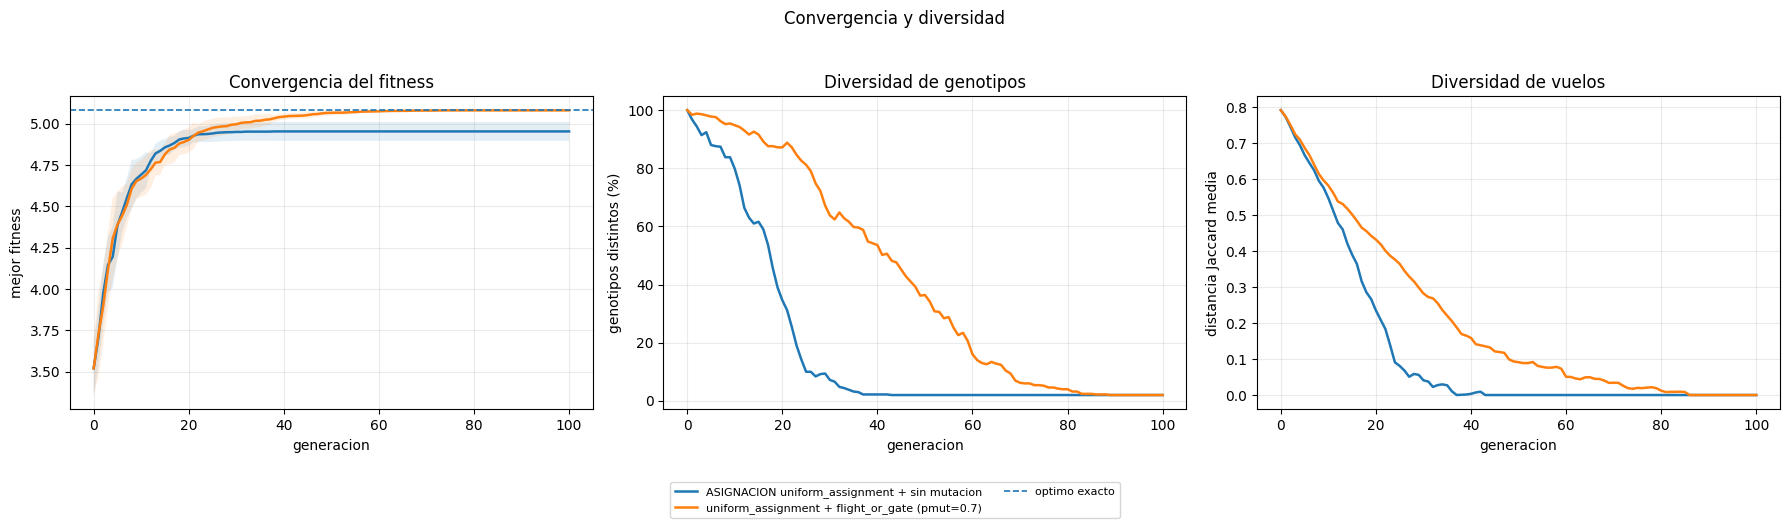

'figuras/convergencia_diversidad.png'

In [ ]:
import os

FIGURES_DIR = "figuras"
os.makedirs(FIGURES_DIR, exist_ok=True)


def plot_selected_experiments(experiments, labels, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

    for label in labels:
        experiment = experiments[label]
        curves = np.asarray([run["curve"] for run in experiment["runs"]], dtype=float)
        unique_curves = np.asarray([
            run["unique_ratio_curve"] for run in experiment["runs"]
        ], dtype=float)
        jaccard_curves = np.asarray([
            run["flight_jaccard_curve"] for run in experiment["runs"]
        ], dtype=float)

        generations = np.arange(curves.shape[1])

        axes[0].plot(generations, curves.mean(axis=0), linewidth=1.8, label=label)
        axes[0].fill_between(
            generations,
            curves.mean(axis=0) - curves.std(axis=0, ddof=1),
            curves.mean(axis=0) + curves.std(axis=0, ddof=1),
            alpha=0.12
        )

        axes[1].plot(
            generations,
            100 * unique_curves.mean(axis=0),
            linewidth=1.8,
            label=label
        )

        axes[2].plot(
            generations,
            jaccard_curves.mean(axis=0),
            linewidth=1.8,
            label=label
        )

    axes[0].axhline(
        GLOBAL_OPTIMUM_FITNESS,
        linestyle="--",
        linewidth=1.2,
        label="optimo exacto"
    )
    axes[0].set_title("Convergencia del fitness")
    axes[0].set_xlabel("generacion")
    axes[0].set_ylabel("mejor fitness")

    axes[1].set_title("Diversidad de genotipos")
    axes[1].set_xlabel("generacion")
    axes[1].set_ylabel("genotipos distintos (%)")

    axes[2].set_title("Diversidad de vuelos")
    axes[2].set_xlabel("generacion")
    axes[2].set_ylabel("distancia Jaccard media")

    for ax in axes:
        ax.grid(alpha=0.25)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_legend, loc="lower center", ncol=2, fontsize=8)
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0.10, 1, 0.95))

    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


labels_for_diagnostics = [
    label_no_mutation,
    BEST_MUTATION_LABEL,
]

plot_selected_experiments(
    experiments_stage2,
    labels_for_diagnostics,
    "Convergencia y diversidad",
    "convergencia_diversidad.png"
)


/tmp/ipykernel_2028/4232104551.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_values, labels=[label.replace(BEST_CROSSOVER + " + ", "") for label in mutation_labels],


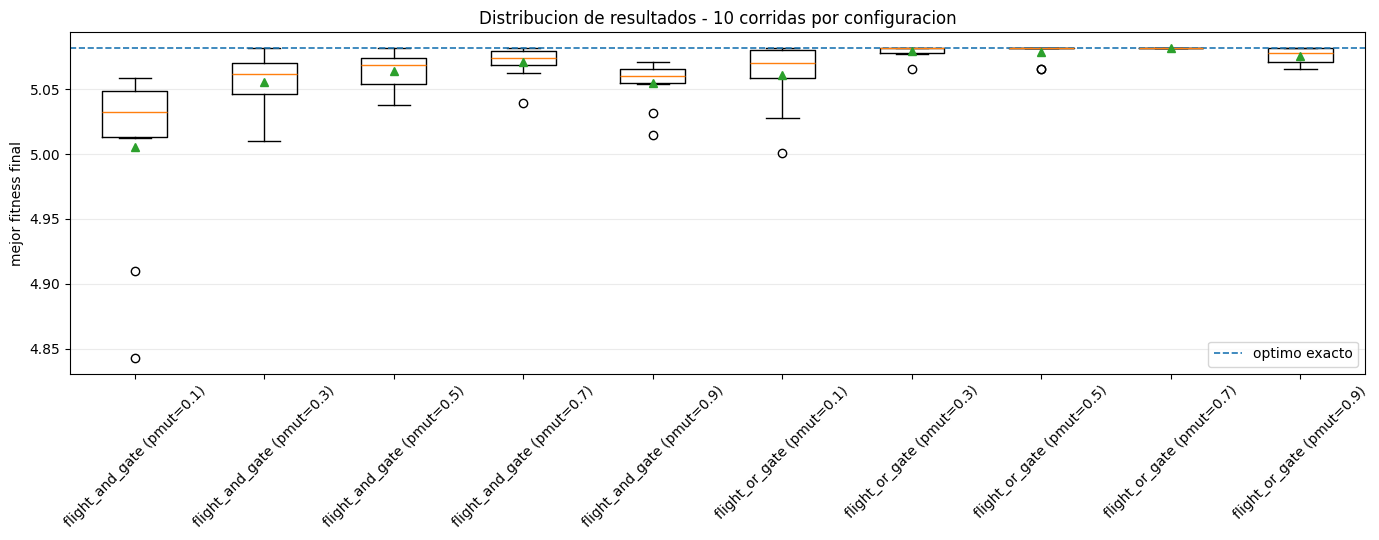

In [ ]:
# Distribucion del fitness final por configuracion de mutacion
mutation_labels = [
    label for label in experiments_stage2
    if label != label_no_mutation
]

fig, ax = plt.subplots(figsize=(14, 5.5))
box_values = [
    [run["best_fitness"] for run in experiments_stage2[label]["runs"]]
    for label in mutation_labels
]
ax.boxplot(box_values, labels=[label.replace(BEST_CROSSOVER + " + ", "") for label in mutation_labels],
           showmeans=True)
ax.axhline(GLOBAL_OPTIMUM_FITNESS, linestyle="--", linewidth=1.2, label="optimo exacto")
ax.set_ylabel("mejor fitness final")
ax.set_title("Distribucion de resultados - 10 corridas por configuracion")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "boxplot_mutaciones.png"), dpi=160, bbox_inches="tight")
plt.show()


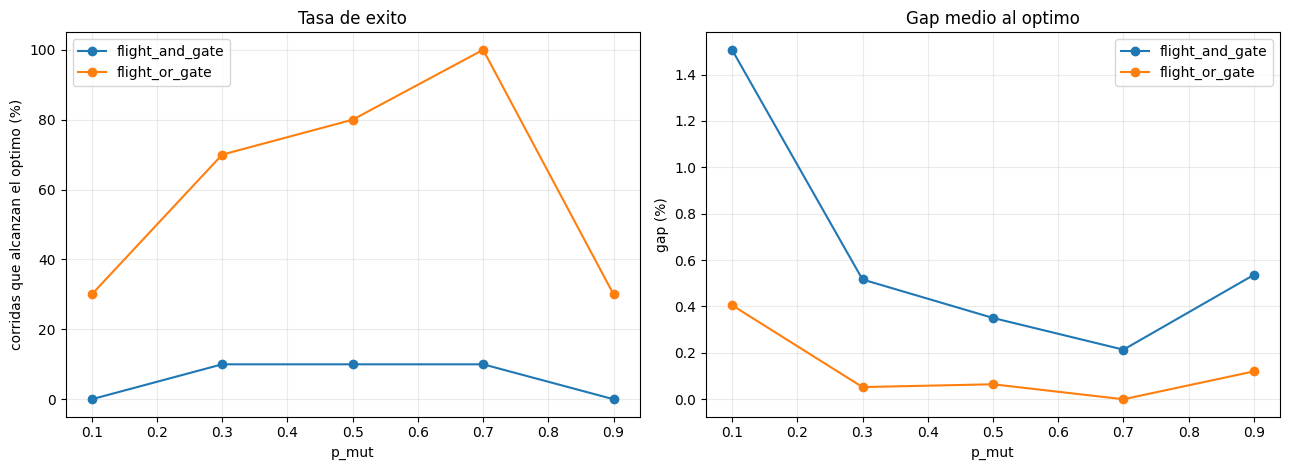

In [ ]:
# Tasa de exito y gap medio por operador/tasa
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for mutation_operator in MUTATION_OPERATORS:
    success = []
    gap = []
    for rate in MUTATION_RATES:
        label = "{} + {} (pmut={})".format(
            BEST_CROSSOVER, mutation_operator, rate
        )
        summary = summarize(experiments_stage2[label])
        success.append(summary["exito (%)"])
        gap.append(summary["gap medio (%)"])

    axes[0].plot(MUTATION_RATES, success, marker="o", label=mutation_operator)
    axes[1].plot(MUTATION_RATES, gap, marker="o", label=mutation_operator)

axes[0].set_title("Tasa de exito")
axes[0].set_xlabel("p_mut")
axes[0].set_ylabel("corridas que alcanzan el optimo (%)")
axes[0].set_ylim(-5, 105)

axes[1].set_title("Gap medio al optimo")
axes[1].set_xlabel("p_mut")
axes[1].set_ylabel("gap (%)")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exito_gap_mutacion.png"), dpi=160, bbox_inches="tight")
plt.show()


## 14. Mejor solución monoobjetivo

Se selecciona el mejor individuo de las 10 corridas de la configuración elegida y se muestra
la programación completa, junto con su gap respecto al óptimo exacto.


In [ ]:
def detailed_solution_report(ind, title):
    print(title)
    print("=" * len(title))
    print(
        "{:>8} {:>10} {:>8} {:>8} {:>16} {:>14}".format(
            "vuelo", "pasajeros", "gate", "tipo",
            "t.desembarque", "eficiencia"
        )
    )

    total_passengers = 0
    total_time = 0.0

    for flight, gate in zip(ind.flights, ind.gates):
        time_value = disembarkation_time(flight, gate)
        total_passengers += flight.number_of_passengers
        total_time += time_value

        print(
            "{:>8} {:>10} {:>8} {:>8} {:>16.2f} {:>14.4f}".format(
                flight.identifier,
                flight.number_of_passengers,
                gate.identifier,
                "Zone" if isinstance(gate, Zone) else "Sleeve",
                time_value,
                flight.number_of_passengers / time_value
            )
        )

    print("-" * 76)
    print("Fitness monoobjetivo : {:.12f}".format(ind.fitness))
    print("Pasajeros totales    : {}".format(total_passengers))
    print("Tiempo total          : {:.2f}".format(total_time))
    print("Valido                : {}".format(is_valid(ind)))

    if is_valid(ind):
        gap = max(
            0.0,
            100.0 * (GLOBAL_OPTIMUM_FITNESS - ind.fitness) / GLOBAL_OPTIMUM_FITNESS
        )
        print("Gap al optimo         : {:.6f}%".format(gap))


winner_experiment = BEST_MUTATION_EXPERIMENT
BEST_MONO_INDIVIDUAL = max(
    (run["individual"] for run in winner_experiment["runs"]),
    key=lambda ind: ind.fitness
)

detailed_solution_report(
    BEST_MONO_INDIVIDUAL,
    "MEJOR SOLUCION MONOOBJETIVO"
)

print("\nOptimo exacto de referencia: {:.12f}".format(GLOBAL_OPTIMUM_FITNESS))
print(
    "Tasa de exito de la configuracion: {:.1f}%".format(
        summarize(winner_experiment)["exito (%)"]
    )
)


MEJOR SOLUCION MONOOBJETIVO
   vuelo  pasajeros     gate     tipo    t.desembarque     eficiencia
      28         54        9     Zone            51.07         1.0575
       3         66        2     Zone            80.07         0.8243
      18         55        5   Sleeve           158.73         0.3465
      12         25        3   Sleeve           242.55         0.1031
      16         12        8   Sleeve            54.29         0.2211
      13         22        0     Zone            33.55         0.6557
       4         71        4   Sleeve           110.94         0.6400
      25         59        7   Sleeve           208.43         0.2831
       9         68        1   Sleeve           143.12         0.4751
       7         34        6   Sleeve            71.49         0.4756
----------------------------------------------------------------------------
Fitness monoobjetivo : 5.081936224828
Pasajeros totales    : 466
Tiempo total          : 1154.21
Valido                : True

---
# PARTE B - Algoritmo multiobjetivo NSGA-II

## 14. Por que multiobjetivo

El fitness mono-objetivo, $\sum_i p_i / t_i$, mezcla en un solo numero dos cosas que en la operacion
aeroportuaria se deciden por separado:

- f1 = numero total de pasajeros de los vuelos escogidos (se quiere maximizar): es el servicio
  prestado, los pasajeros que efectivamente se atienden.
- f2 = tiempo total de desembarque de esos vuelos en sus gates (se quiere minimizar): es el uso
  del recurso, cuanto tiempo permanecen ocupadas las puertas.

Estos objetivos estan en conflicto: aceptar un vuelo mas grande suma pasajeros pero tambien suma
tiempo de desembarque. El cociente mono-objetivo esconde ese conflicto: entrega una sola solucion y no
permite al planificador ver si existe otra que atienda 200 pasajeros mas a costa de 5 minutos adicionales.

NSGA-II (Non-dominated Sorting Genetic Algorithm II, Deb et al., 2002) no busca una solucion sino un
conjunto de soluciones de compromiso. Conceptos clave:

- Dominancia de Pareto: la solucion A domina a B si A es al menos tan buena como B en todos los
  objetivos y estrictamente mejor en al menos uno. Aqui: A domina a B si `f1(A) >= f1(B)` y
  `f2(A) <= f2(B)`, con al menos una desigualdad estricta.
- Frontera de Pareto: el conjunto de soluciones que nadie domina. Son las opciones racionales:
  para mejorar cualquiera de ellas en un objetivo hay que empeorar el otro.
- Non-dominated sorting: ordena la poblacion en capas ("frentes"). El frente 1 son las no dominadas;
  el frente 2 son las que solo eran dominadas por el frente 1, y asi sucesivamente. El `rank` de un
  individuo es el numero de su frente: menor rank = mejor.
- Crowding distance (distancia de apiñamiento): dentro de un mismo frente, todos los individuos son
  igual de "buenos", asi que se desempata por diversidad: se mide que tan solo esta cada punto (el
  tamaño del rectangulo que forman sus vecinos inmediatos en el espacio de objetivos). Los individuos en
  zonas poco pobladas se prefieren, para que la frontera quede bien repartida y no se apelotone en un
  extremo. Los extremos reciben distancia infinita para no perderlos nunca.
- Operador de comparacion apiñada: entre dos individuos gana el de menor `rank`; si empatan, el de
  mayor `crowding_distance`.
- Elitismo (mu + lambda): padres e hijos compiten juntos; se llenan los sobrevivientes frente por
  frente y, cuando un frente no cabe completo, se corta por `crowding_distance`.

La representacion del cromosoma es exactamente la misma que en el mono-objetivo, y los operadores de
cruzamiento y mutacion son los mismos desarrollados en la Parte A. Solo cambian la evaluacion (dos
objetivos en vez de uno), la seleccion de padres y el reemplazo.


In [ ]:
class IndividualNSGA(IndividualGA):
    """Individuo para NSGA-II.

    Hereda el cromosoma y TODOS los operadores validos de IndividualGA, y agrega los atributos que necesita
    el ordenamiento por no-dominancia:
      objectives         : tupla (total_passengers, total_disembarkation_time); None = no evaluado
      rank               : numero del frente de Pareto al que pertenece (0 = frente no dominado)
      crowding_distance  : medida de que tan aislado esta el individuo dentro de su frente
      domination_count   : cuantos individuos lo dominan (auxiliar del ordenamiento)
      dominated_solutions: individuos a los que domina (auxiliar del ordenamiento)
    """

    def __init__(self, flights, gates, flights_pool, gates_pool):
        super().__init__(flights, gates, flights_pool, gates_pool)
        self.objectives = None
        self.rank = None
        self.crowding_distance = 0.0
        self.domination_count = 0
        self.dominated_solutions = []


In [ ]:
def objectives_flights_gates(flights, gates):
  """Los dos objetivos del problema.

  f1 = total de pasajeros de los vuelos escogidos           -> MAXIMIZAR
  f2 = tiempo total de desembarque en los gates asignados   -> MINIMIZAR
  """
  total_passengers = sum(flight.number_of_passengers for flight in flights)
  total_disembarkation_time = sum(disembarkation_time(flight, gate) for flight, gate in zip(flights, gates))
  return (total_passengers, total_disembarkation_time)


def evaluate_population_multiobjective(population, objectives_fn):
  "Evalua los objetivos de los individuos aun no evaluados"
  for individual in population:
    if individual.objectives is None:
      individual.objectives = objectives_fn(individual.flights, individual.gates)


def dominates(individual_a, individual_b):
  """True si individual_a domina a individual_b.

  Dominancia con f1 a maximizar (pasajeros) y f2 a minimizar (tiempo).
  """
  at_least_as_good = (individual_a.objectives[0] >= individual_b.objectives[0]) and \
                     (individual_a.objectives[1] <= individual_b.objectives[1])
  strictly_better = (individual_a.objectives[0] > individual_b.objectives[0]) or \
                    (individual_a.objectives[1] < individual_b.objectives[1])
  return at_least_as_good and strictly_better


In [ ]:
def fast_nondominated_sort(population):
  """Ordena la poblacion en frentes de Pareto. Retorna una lista de frentes (listas de individuos).

  fronts[0] son los individuos no dominados por nadie, fronts[1] los dominados solo por fronts[0], etc.
  Ademas asigna el atributo rank a cada individuo.
  """
  for individual in population:
    individual.domination_count = 0
    individual.dominated_solutions = []

  # comparacion por pares (cada par se evalua una sola vez)
  for i in range(len(population)):
    for j in range(i + 1, len(population)):
      individual_i, individual_j = population[i], population[j]
      if dominates(individual_i, individual_j):
        individual_i.dominated_solutions.append(individual_j)
        individual_j.domination_count += 1
      elif dominates(individual_j, individual_i):
        individual_j.dominated_solutions.append(individual_i)
        individual_i.domination_count += 1

  fronts = [[]]
  for individual in population:
    if individual.domination_count == 0:
      individual.rank = 0
      fronts[0].append(individual)

  front_index = 0
  while len(fronts[front_index]) > 0:
    next_front = []
    for individual in fronts[front_index]:
      for dominated in individual.dominated_solutions:
        dominated.domination_count -= 1
        if dominated.domination_count == 0:
          dominated.rank = front_index + 1
          next_front.append(dominated)
    front_index += 1
    fronts.append(next_front)

  fronts.pop()  # el ultimo frente generado siempre queda vacio
  return fronts


def crowding_distance_assignment(front):
  """Asigna la distancia de apiñamiento a los individuos de un frente.

  Para cada objetivo se ordena el frente y se mide la distancia entre los vecinos de cada individuo,
  normalizada por el rango del objetivo. Los extremos reciben distancia infinita para preservarlos.
  """
  number_of_individuals = len(front)
  if number_of_individuals == 0:
    return
  for individual in front:
    individual.crowding_distance = 0.0
  if number_of_individuals <= 2:
    for individual in front:
      individual.crowding_distance = float("inf")
    return

  number_of_objectives = len(front[0].objectives)
  for objective_index in range(number_of_objectives):
    front.sort(key=lambda individual: individual.objectives[objective_index])
    front[0].crowding_distance = float("inf")
    front[-1].crowding_distance = float("inf")

    objective_range = front[-1].objectives[objective_index] - front[0].objectives[objective_index]
    if objective_range == 0:
      continue
    for i in range(1, number_of_individuals - 1):
      distance = front[i + 1].objectives[objective_index] - front[i - 1].objectives[objective_index]
      front[i].crowding_distance += distance / objective_range


def crowded_comparison(individual_a, individual_b):
  "True si individual_a es preferible a individual_b: menor rank, o mismo rank y mayor crowding distance"
  if individual_a.rank != individual_b.rank:
    return individual_a.rank < individual_b.rank
  return individual_a.crowding_distance > individual_b.crowding_distance


def select_parents_tournament_crowded(population, tournament_size=2):
  """Seleccion de dos padres por torneo con el operador de comparacion apiñada de NSGA-II.

  Reemplaza a la ruleta del mono-objetivo: aqui no hay un fitness escalar sobre el cual girarla.
  """
  def run_tournament(excluded=None):
    candidates_indexes = np.random.permutation(len(population))
    candidates = [population[i] for i in candidates_indexes if population[i] is not excluded][:tournament_size]
    winner = candidates[0]
    for candidate in candidates[1:]:
      if crowded_comparison(candidate, winner):
        winner = candidate
    return winner

  parent1 = run_tournament()
  parent2 = run_tournament(excluded=parent1)
  return (parent1, parent2)


def select_survivors_nsga2(population, offspring_population, numsurvivors):
  """Reemplazo elitista (mu + lambda) de NSGA-II.

  Junta padres e hijos, los ordena en frentes y llena la siguiente generacion frente por frente.
  El frente que no cabe completo se corta priorizando mayor crowding distance (mas diversidad).
  """
  combined_population = population + offspring_population
  fronts = fast_nondominated_sort(combined_population)

  next_population = []
  for front in fronts:
    crowding_distance_assignment(front)
    if len(next_population) + len(front) <= numsurvivors:
      next_population.extend(front)
    else:
      front.sort(key=lambda individual: individual.crowding_distance, reverse=True)
      next_population.extend(front[:numsurvivors - len(next_population)])
      break
  return next_population


### 14.1 El bucle de NSGA-II

Mismo esqueleto del AG mono-objetivo (inicializar, seleccionar padres, cruzar, mutar, evaluar, reemplazar),
cambiando solo tres piezas:

| Pieza | Mono-objetivo | NSGA-II |
|---|---|---|
| Evaluacion | `fitness` escalar | vector `(f1, f2)` |
| Seleccion de padres | ruleta proporcional al fitness | torneo binario con comparacion apiñada |
| Reemplazo | ranking por fitness | frentes de Pareto + crowding distance |

Los operadores de cruzamiento y mutacion son exactamente los mismos de la Parte A.


In [ ]:
def nsga2(list_of_flights, list_of_gates, num_individuals, flights_to_assign, objectives_fn, n_generations,
          crossover="uniform_assignment", mutation="flight_and_gate", p_mut=0.3, verbose=True):
  """Algoritmo NSGA-II. Retorna (population, pareto_front, history)."""

  # Inicializa una poblacion inicial de forma aleatoria (individuos factibles)
  population = init_population(num_individuals, flights_to_assign, list_of_flights, list_of_gates, IndividualNSGA)
  evaluate_population_multiobjective(population, objectives_fn)

  fronts = fast_nondominated_sort(population)
  for front in fronts:
    crowding_distance_assignment(front)

  history = []
  for g in range(n_generations):  # ciclo evolutivo

    ## Crea la poblacion descendencia (torneo binario apiñado + cruzamiento + mutacion)
    offspring_population = []
    while len(offspring_population) < num_individuals:
      parent1, parent2 = select_parents_tournament_crowded(population)

      if crossover == "onepoint_assignment":
        children = parent1.crossover_onepoint_assignment(parent2)
      elif crossover == "uniform_assignment":
        children = parent1.crossover_uniform_assignment(parent2)
      elif crossover == "onepoint":
        children = parent1.crossover_onepoint(parent2)
      elif crossover == "uniform":
        children = parent1.crossover_uniform(parent2)
      else:
        raise NotImplementedError

      for child in children:
        if p_mut > 0 and uniform(0, 1) < p_mut:
          if mutation == "flight_and_gate":
            child = child.mutate_flight_and_gate()
          elif mutation == "flight_or_gate":
            child = child.mutate_flight_or_gate()
          elif mutation == "flight":
            child = child.mutate_flight()
          elif mutation == "gate":
            child = child.mutate_gate()
          elif mutation == "position":
            child = child.mutate_position()
          else:
            raise NotImplementedError(mutation)
        offspring_population.append(child)

    offspring_population = offspring_population[:num_individuals]

    ## Evalua los objetivos de la descendencia
    evaluate_population_multiobjective(offspring_population, objectives_fn)

    ## Reemplazo elitista por frentes de Pareto + crowding distance
    population = select_survivors_nsga2(population, offspring_population, num_individuals)

    ## Historia: tamaño del frente no dominado y extremos de los objetivos
    current_front = [individual for individual in population if individual.rank == 0]
    history.append({
        "generacion": g,
        "tamaño frente": len(current_front),
        "max pasajeros": max(individual.objectives[0] for individual in current_front),
        "min tiempo": min(individual.objectives[1] for individual in current_front),
    })

    if verbose and (g % 20 == 0):
      print("generacion {}: frente de Pareto con {} individuos | max pasajeros = {} | min tiempo = {:.1f}".format(
          g, len(current_front), history[-1]["max pasajeros"], history[-1]["min tiempo"]))

  # Frente de Pareto final
  fronts = fast_nondominated_sort(population)
  for front in fronts:
    crowding_distance_assignment(front)
  return population, fronts[0], history


## 16. Experimentación multiobjetivo

Se utiliza la misma instancia de 30 vuelos y 10 Gates.

Parámetros solicitados:

- población: 50 individuos;
- generaciones: 100;
- corridas independientes: 5.

Los operadores de asignación seleccionados en el experimento monoobjetivo se utilizan también en NSGA-II.


In [ ]:
NSGA_POPULATION_SIZE = 50
NSGA_GENERATIONS = 100
NSGA_RUNS = 5


def unique_objective_points(front):
  "Puntos (f1, f2) distintos de un frente, ordenados por f1"
  return sorted(set(individual.objectives for individual in front))


def filter_nondominated_points(points):
  "Filtra una lista de puntos (f1 max, f2 min) dejando solo los no dominados"
  nondominated = []
  for point in points:
    dominated_by_other = any(
        (other[0] >= point[0] and other[1] <= point[1]) and (other[0] > point[0] or other[1] < point[1])
        for other in points)
    if not dominated_by_other:
      nondominated.append(point)
  return sorted(set(nondominated))


def hypervolume(points, reference_point):
  """Hipervolumen 2D (aqui: area) dominada por un conjunto de puntos, con f1 a maximizar y f2 a minimizar.

  Cada punto (f1, f2) domina el rectangulo [f1_ref, f1] x [f2, f2_ref]. El hipervolumen es el area de la
  union de esos rectangulos, calculada con un barrido sobre los puntos ordenados por f1 descendente.
  """
  valid_points = [p for p in points if p[0] >= reference_point[0] and p[1] <= reference_point[1]]
  if len(valid_points) == 0:
    return 0.0
  swept_points = sorted(set(valid_points), key=lambda p: (-p[0], p[1]))

  area = 0.0
  previous_time = reference_point[1]
  for passengers, time_value in swept_points:
    if time_value < previous_time:  # solo los puntos que aportan area nueva
      area += (passengers - reference_point[0]) * (previous_time - time_value)
      previous_time = time_value
  return area


In [ ]:
nsga_results = []
print("Ejecutando NSGA-II: {} corridas x {} generaciones, poblacion {}".format(
    NSGA_RUNS, NSGA_GENERATIONS, NSGA_POPULATION_SIZE))
print("Cruzamiento: {} | Mutacion: {} | p_mut = {}\n".format(BEST_CROSSOVER, BEST_MUTATION_OPERATOR, BEST_MUTATION_RATE))

for r in range(NSGA_RUNS):
  seed(BASE_SEED + r)
  np.random.seed(BASE_SEED + r)

  start_time = time.time()
  final_population, pareto_front, history = nsga2(
      list_of_flights, list_of_gates, NSGA_POPULATION_SIZE, flights_to_assign, objectives_flights_gates,
      NSGA_GENERATIONS, crossover=BEST_CROSSOVER, mutation=BEST_MUTATION_OPERATOR, p_mut=BEST_MUTATION_RATE,
      verbose=False)
  elapsed_time = time.time() - start_time

  points = unique_objective_points(pareto_front)
  nsga_results.append({
      "run": r,
      "front": pareto_front,
      "points": points,
      "history": history,
      "time_s": elapsed_time,
  })
  print("corrida {}: {} individuos en el frente ({} puntos distintos) | pasajeros [{} - {}] | tiempo [{:.1f} - {:.1f}] | {:.2f} s".format(
      r, len(pareto_front), len(points),
      min(p[0] for p in points), max(p[0] for p in points),
      min(p[1] for p in points), max(p[1] for p in points), elapsed_time))


Ejecutando NSGA-II: 5 corridas x 100 generaciones, poblacion 50
Cruzamiento: uniform_assignment | Mutacion: flight_or_gate | p_mut = 0.7

corrida 0: 50 individuos en el frente (42 puntos distintos) | pasajeros [321 - 653] | tiempo [764.6 - 2201.6] | 0.33 s
corrida 1: 50 individuos en el frente (37 puntos distintos) | pasajeros [365 - 645] | tiempo [801.7 - 2190.0] | 0.31 s
corrida 2: 50 individuos en el frente (40 puntos distintos) | pasajeros [289 - 653] | tiempo [699.0 - 2202.3] | 0.33 s
corrida 3: 50 individuos en el frente (42 puntos distintos) | pasajeros [321 - 653] | tiempo [732.6 - 2222.8] | 0.32 s
corrida 4: 50 individuos en el frente (40 puntos distintos) | pasajeros [289 - 653] | tiempo [716.6 - 2202.0] | 0.30 s


In [ ]:
# Punto de referencia comun (nadir de todas las corridas, con un 2% de margen) para el hipervolumen
all_points = [point for result in nsga_results for point in result["points"]]
reference_point = (min(p[0] for p in all_points) * 0.98, max(p[1] for p in all_points) * 1.02)
print("Punto de referencia para el hipervolumen: ({:.1f} pasajeros, {:.1f} unidades de tiempo)\n".format(*reference_point))

header = "{:>8} {:>16} {:>18} {:>16} {:>16} {:>12}".format("corrida", "tam. frente", "puntos distintos", "max pasajeros", "min tiempo", "hipervolumen")
print(header)
print("-" * len(header))
hypervolumes = []
for result in nsga_results:
  hv = hypervolume(result["points"], reference_point)
  result["hypervolume"] = hv
  hypervolumes.append(hv)
  print("{:>8} {:>16} {:>18} {:>16} {:>16.1f} {:>12.1f}".format(
      result["run"], len(result["front"]), len(result["points"]),
      max(p[0] for p in result["points"]), min(p[1] for p in result["points"]), hv))
print("-" * len(header))
print("{:>8} {:>16.1f} {:>18} {:>16} {:>16} {:>12.1f}".format(
    "media", np.mean([len(r["front"]) for r in nsga_results]), "", "", "", np.mean(hypervolumes)))
print("{:>8} {:>16.1f} {:>18} {:>16} {:>16} {:>12.1f}".format(
    "std", np.std([len(r["front"]) for r in nsga_results], ddof=1), "", "", "", np.std(hypervolumes, ddof=1)))
print("\nTiempo promedio por corrida NSGA-II: {:.2f} s".format(np.mean([r["time_s"] for r in nsga_results])))


Punto de referencia para el hipervolumen: (283.2 pasajeros, 2267.2 unidades de tiempo)

 corrida      tam. frente   puntos distintos    max pasajeros       min tiempo hipervolumen
-------------------------------------------------------------------------------------------
       0               50                 42              653            764.6     403123.8
       1               50                 37              645            801.7     398037.5
       2               50                 40              653            699.0     403775.7
       3               50                 42              653            732.6     403548.5
       4               50                 40              653            716.6     397655.5
-------------------------------------------------------------------------------------------
   media             50.0                                                          401228.2
     std              0.0                                                           

## 17. Fronteras de Pareto y soluciones monoobjetivo

Cada punto representa una programación completa de 10 vuelos:

- eje X: pasajeros totales (maximizar);
- eje Y: tiempo total de desembarque (minimizar).

Las estrellas representan las mejores soluciones del AG monoobjetivo proyectadas en el espacio de objetivos.


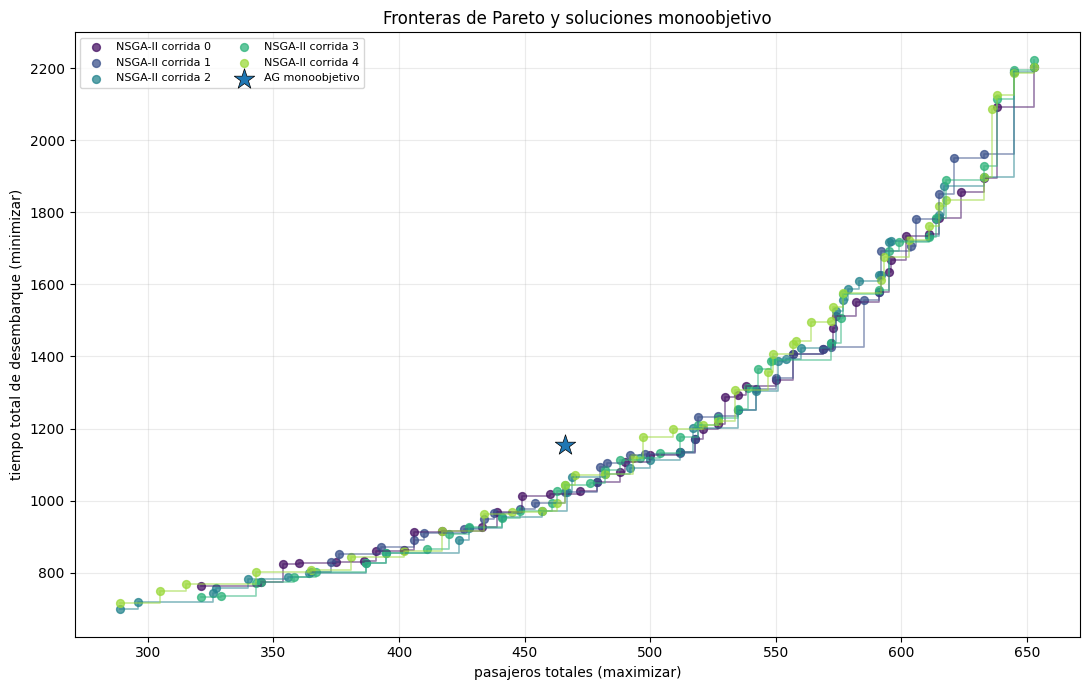

In [ ]:
mono_objective_points = [
    objectives_flights_gates(run["individual"].flights, run["individual"].gates)
    for run in winner_experiment["runs"]
]

all_points = [
    point
    for result in nsga_results
    for point in result["points"]
]
combined_front_points = filter_nondominated_points(all_points)

fig, ax = plt.subplots(figsize=(11, 7))

colors = plt.cm.viridis(np.linspace(0.05, 0.85, NSGA_RUNS))

for result, color in zip(nsga_results, colors):
    points = sorted(result["points"])
    ax.step(
        [p[0] for p in points],
        [p[1] for p in points],
        where="post",
        color=color,
        alpha=0.55,
        linewidth=1.2
    )
    ax.scatter(
        [p[0] for p in points],
        [p[1] for p in points],
        color=color,
        s=32,
        alpha=0.75,
        label="NSGA-II corrida {}".format(result["run"])
    )

unique_mono_points = sorted(set(mono_objective_points))
ax.scatter(
    [p[0] for p in unique_mono_points],
    [p[1] for p in unique_mono_points],
    marker="*",
    s=240,
    edgecolors="black",
    linewidths=0.5,
    zorder=5,
    label="AG monoobjetivo"
)

ax.set_xlabel("pasajeros totales (maximizar)")
ax.set_ylabel("tiempo total de desembarque (minimizar)")
ax.set_title("Fronteras de Pareto y soluciones monoobjetivo")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fronteras_pareto.png"), dpi=170, bbox_inches="tight")
plt.show()


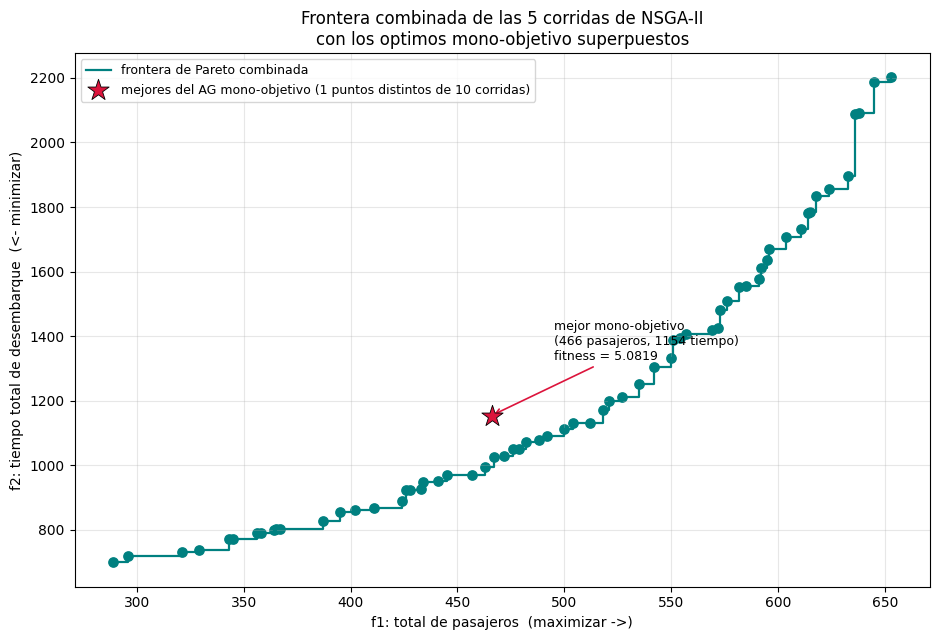

In [ ]:
# Zoom: frontera combinada vs. soluciones mono-objetivo
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.step([p[0] for p in combined_front_points], [p[1] for p in combined_front_points], where="post",
        color="teal", linewidth=1.6, label="frontera de Pareto combinada")
ax.scatter([p[0] for p in combined_front_points], [p[1] for p in combined_front_points], s=45, color="teal")
unique_mono_points = sorted(set(mono_objective_points))
ax.scatter([p[0] for p in unique_mono_points], [p[1] for p in unique_mono_points],
           marker="*", s=260, color="crimson", edgecolors="black", linewidths=0.6, zorder=5,
           label="mejores del AG mono-objetivo ({} puntos distintos de {} corridas)".format(
               len(unique_mono_points), NUMBER_OF_RUNS))

# se rotula solo el mejor individuo mono-objetivo (los demas se agrupan en la misma zona)
best_mono_objective_point = objectives_flights_gates(BEST_MONO_INDIVIDUAL.flights, BEST_MONO_INDIVIDUAL.gates)
ax.annotate("mejor mono-objetivo\n({} pasajeros, {:.0f} tiempo)\nfitness = {:.4f}".format(
    best_mono_objective_point[0], best_mono_objective_point[1], BEST_MONO_INDIVIDUAL.fitness),
    best_mono_objective_point, textcoords="offset points", xytext=(45, 40), fontsize=9,
    arrowprops=dict(arrowstyle="->", color="crimson", linewidth=1.2))

ax.set_xlabel("f1: total de pasajeros  (maximizar ->)")
ax.set_ylabel("f2: tiempo total de desembarque  (<- minimizar)")
ax.set_title("Frontera combinada de las {} corridas de NSGA-II\ncon los optimos mono-objetivo superpuestos".format(NSGA_RUNS))
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pareto_combinada.png"), dpi=130, bbox_inches="tight")
plt.show()


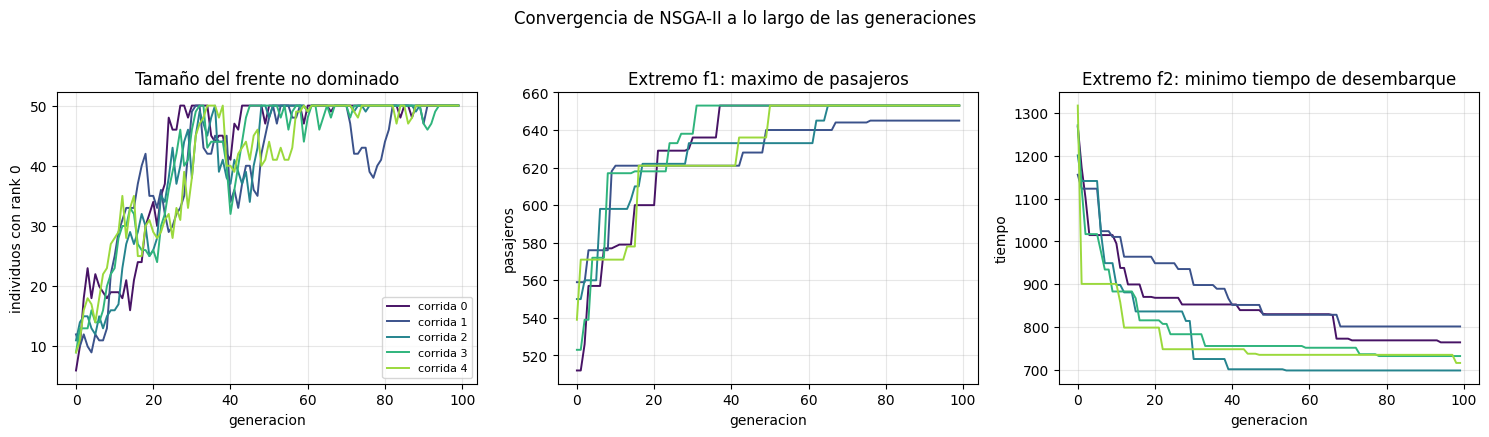

In [ ]:
# Evolucion del frente a lo largo de las generaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for result, color in zip(nsga_results, colors):
  generations = [h["generacion"] for h in result["history"]]
  axes[0].plot(generations, [h["tamaño frente"] for h in result["history"]], color=color, linewidth=1.4,
               label="corrida {}".format(result["run"]))
  axes[1].plot(generations, [h["max pasajeros"] for h in result["history"]], color=color, linewidth=1.4)
  axes[2].plot(generations, [h["min tiempo"] for h in result["history"]], color=color, linewidth=1.4)

axes[0].set_title("Tamaño del frente no dominado"); axes[0].set_xlabel("generacion"); axes[0].set_ylabel("individuos con rank 0")
axes[1].set_title("Extremo f1: maximo de pasajeros"); axes[1].set_xlabel("generacion"); axes[1].set_ylabel("pasajeros")
axes[2].set_title("Extremo f2: minimo tiempo de desembarque"); axes[2].set_xlabel("generacion"); axes[2].set_ylabel("tiempo")
for ax in axes:
  ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.suptitle("Convergencia de NSGA-II a lo largo de las generaciones", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "nsga2_convergencia.png"), dpi=130, bbox_inches="tight")
plt.show()


## 18. Soluciones representativas de la frontera de Pareto

Se presentan tres alternativas:

- máximo servicio: mayor número de pasajeros;
- máxima rapidez: menor tiempo total;
- mejor relación pasajeros/tiempo: maximiza \(f_1/f_2\) dentro de la frontera.


In [ ]:
best_nsga_run = max(nsga_results, key=lambda result: result["hypervolume"])
front_individuals = best_nsga_run["front"]

solution_max_passengers = max(front_individuals, key=lambda ind: ind.objectives[0])
solution_min_time = min(front_individuals, key=lambda ind: ind.objectives[1])
solution_best_ratio = max(front_individuals, key=lambda ind: ind.objectives[0] / ind.objectives[1])

for individual in [solution_max_passengers, solution_min_time, solution_best_ratio]:
  individual.fitness = fitness(individual.flights, individual.gates)

print("Corrida NSGA-II con mayor hipervolumen: corrida {}\n".format(best_nsga_run["run"]))
detailed_solution_report(solution_max_passengers, "PARETO - extremo de SERVICIO (maximos pasajeros)")
detailed_solution_report(solution_min_time, "PARETO - extremo de RAPIDEZ (minimo tiempo)")
detailed_solution_report(solution_best_ratio, "PARETO - mejor relacion pasajeros/tiempo")


Corrida NSGA-II con mayor hipervolumen: corrida 2

PARETO - extremo de SERVICIO (maximos pasajeros)
   vuelo  pasajeros     gate     tipo    t.desembarque     eficiencia
      18         55        3   Sleeve           503.69         0.1092
      20         77        0     Zone           135.21         0.5695
      28         54        6   Sleeve           161.28         0.3348
      25         59        7   Sleeve           208.43         0.2831
       9         68        5   Sleeve           234.15         0.2904
      27         76        9     Zone           205.36         0.3701
      21         73        2     Zone           203.41         0.3589
       3         66        1   Sleeve           125.87         0.5244
       4         71        4   Sleeve           110.94         0.6400
      10         54        8   Sleeve           313.98         0.1720
----------------------------------------------------------------------------
Fitness monoobjetivo : 3.652302762771
Pasajeros total

In [ ]:
# Tabla completa del frente de Pareto de la mejor corrida
print("FRENTE DE PARETO COMPLETO - corrida {} ({} puntos distintos)\n".format(
    best_nsga_run["run"], len(best_nsga_run["points"])))
print("{:>4} {:>14} {:>18} {:>18} {:>16}".format("#", "f1 pasajeros", "f2 tiempo total", "f1/f2", "fitness mono"))
print("-" * 74)
for i, point in enumerate(sorted(best_nsga_run["points"])):
  representative = next(ind for ind in front_individuals if ind.objectives == point)
  print("{:>4} {:>14} {:>18.2f} {:>18.4f} {:>16.4f}".format(
      i + 1, point[0], point[1], point[0] / point[1], fitness(representative.flights, representative.gates)))


FRENTE DE PARETO COMPLETO - corrida 2 (40 puntos distintos)

   #   f1 pasajeros    f2 tiempo total              f1/f2     fitness mono
--------------------------------------------------------------------------
   1            289             698.98             0.4135           4.5316
   2            296             717.78             0.4124           4.4236
   3            326             745.25             0.4374           4.5740
   4            327             756.80             0.4321           4.4593
   5            340             781.86             0.4349           4.5405
   6            356             789.12             0.4511           4.6500
   7            364             800.53             0.4547           4.6362
   8            387             826.96             0.4680           4.6582
   9            395             855.30             0.4618           4.6391
  10            424             889.82             0.4765           4.7471
  11            428             924.62 

In [ ]:
# Comparacion directa: mono-objetivo vs NSGA-II en el espacio de objetivos
best_mono_point = objectives_flights_gates(BEST_MONO_INDIVIDUAL.flights, BEST_MONO_INDIVIDUAL.gates)
dominating_solutions = [p for p in combined_front_points
                        if (p[0] >= best_mono_point[0] and p[1] <= best_mono_point[1]) and p != best_mono_point]
best_ratio_of_combined_front = max(combined_front_points, key=lambda p: p[0] / p[1])

print("Mejor individuo mono-objetivo   : f1 = {} pasajeros, f2 = {:.2f}, fitness = {:.4f}".format(
    best_mono_point[0], best_mono_point[1], BEST_MONO_INDIVIDUAL.fitness))
print("Mejor relacion pasajeros/tiempo: f1 = {} pasajeros, f2 = {:.2f}, f1/f2 = {:.4f}".format(
    best_ratio_of_combined_front[0], best_ratio_of_combined_front[1], best_ratio_of_combined_front[0] / best_ratio_of_combined_front[1]))
print("Puntos de la frontera combinada que dominan al mejor mono-objetivo: {}".format(len(dominating_solutions)))
print("Rango de la frontera combinada  : pasajeros [{} - {}], tiempo [{:.1f} - {:.1f}]".format(
    min(p[0] for p in combined_front_points), max(p[0] for p in combined_front_points),
    min(p[1] for p in combined_front_points), max(p[1] for p in combined_front_points)))


Mejor individuo mono-objetivo   : f1 = 466 pasajeros, f2 = 1154.21, fitness = 5.0819
Mejor relacion pasajeros/tiempo: f1 = 424 pasajeros, f2 = 889.82, f1/f2 = 0.4765
Puntos de la frontera combinada que dominan al mejor mono-objetivo: 10
Rango de la frontera combinada  : pasajeros [289 - 653], tiempo [699.0 - 2201.6]


## 18. Exportacion de resultados

Se guardan las tablas en `resultados/` (formato CSV) y las figuras en `figuras/`, para poder incorporarlas
al informe escrito.


In [ ]:
RESULTS_DIR = "resultados"
os.makedirs(RESULTS_DIR, exist_ok=True)


def write_csv(filename, header, rows):
    path = os.path.join(RESULTS_DIR, filename)
    with open(path, "w", encoding="utf-8") as csv_file:
        csv_file.write(";".join(header) + "\n")
        for row in rows:
            csv_file.write(";".join(str(value) for value in row) + "\n")
    return path


# Resumen monoobjetivo
all_experiments = {}
all_experiments.update(experiments_stage1)
all_experiments.update(experiments_stage2)
all_experiments.update(experiments_ablation)

summary_rows = []
for label, experiment in all_experiments.items():
    s = summarize(experiment)
    summary_rows.append([
        label,
        s["media"],
        s["std"],
        s["mejor"],
        s["gap medio (%)"],
        s["exito (%)"],
        s["validez (%)"],
        s["div.unica final (%)"],
        s["jaccard final"],
        s["gen. del mejor"],
        s["tiempo (s)"],
    ])

summary_path = write_csv(
    "resumen_monoobjetivo.csv",
    [
        "configuracion", "media", "std", "mejor", "gap_medio_pct",
        "exito_pct", "validez_pct", "diversidad_unica_final_pct",
        "jaccard_final", "generacion_mejor", "tiempo_s"
    ],
    summary_rows
)


# Detalle de la configuracion seleccionada
selected_rows = []
for run in winner_experiment["runs"]:
    selected_rows.append([
        run["run"],
        run["best_fitness"],
        run["gap_percent"],
        run["reached_optimum"],
        run["gen_best"],
        run["time_s"],
        100 * run["unique_ratio_curve"][-1],
        run["flight_jaccard_curve"][-1],
    ])

selected_path = write_csv(
    "corridas_configuracion_seleccionada.csv",
    [
        "corrida", "best_fitness", "gap_pct", "optimo_alcanzado",
        "generacion_mejor", "tiempo_s", "diversidad_unica_final_pct",
        "jaccard_final"
    ],
    selected_rows
)


# Frentes Pareto
pareto_rows = []
for result in nsga_results:
    for passengers, total_time in result["points"]:
        pareto_rows.append([
            result["run"],
            passengers,
            total_time,
            result["hypervolume"],
        ])

pareto_path = write_csv(
    "nsga2_frentes_pareto.csv",
    ["corrida", "pasajeros", "tiempo_total", "hipervolumen_corrida"],
    pareto_rows
)

print("Archivos generados:")
print(" ", summary_path)
print(" ", selected_path)
print(" ", pareto_path)


Archivos generados:
  resultados/resumen_monoobjetivo.csv
  resultados/corridas_configuracion_seleccionada.csv
  resultados/nsga2_frentes_pareto.csv


---
# 20. Conclusiones automáticas del experimento

La siguiente celda construye las conclusiones directamente a partir de los resultados calculados en esta
ejecución. De esta forma, los valores reportados siempre corresponden a las tablas y figuras del cuaderno.


In [ ]:
selected_summary = summarize(winner_experiment)

print("CONCLUSIONES")
print("=" * 72)
print("Cruzamiento seleccionado :", BEST_CROSSOVER)
print("Mutacion seleccionada    :", BEST_MUTATION_OPERATOR)
print("Tasa de mutacion         :", BEST_MUTATION_RATE)
print("Fitness optimo exacto    : {:.12f}".format(GLOBAL_OPTIMUM_FITNESS))
print("Fitness medio            : {:.12f}".format(selected_summary["media"]))
print("Mejor fitness            : {:.12f}".format(selected_summary["mejor"]))
print("Gap medio                : {:.6f}%".format(selected_summary["gap medio (%)"]))
print("Tasa de exito            : {:.1f}%".format(selected_summary["exito (%)"]))
print("Validez                  : {:.1f}%".format(selected_summary["validez (%)"]))
print("Diversidad final         : {:.1f}%".format(selected_summary["div.unica final (%)"]))
print("Generacion media mejor   : {:.1f}".format(selected_summary["gen. del mejor"]))

stagnated_runs = [
    run for run in winner_experiment["runs"]
    if (not run["reached_optimum"]) and
       (run["gen_best"] <= NUMBER_OF_GENERATIONS - 20)
]

print("Corridas suboptimas con estancamiento >=20 generaciones: {}/{}".format(
    len(stagnated_runs), NUMBER_OF_RUNS
))

print("\nNSGA-II")
print("Corridas                 :", NSGA_RUNS)
print("Poblacion                :", NSGA_POPULATION_SIZE)
print("Generaciones             :", NSGA_GENERATIONS)
print("Mejor hipervolumen       : {:.3f}".format(max(r["hypervolume"] for r in nsga_results)))
print("Puntos no dominados combinados:", len(combined_front_points))

print("\nInterpretacion:")
if selected_summary["exito (%)"] >= 80:
    print("- La configuracion seleccionada alcanza el optimo de referencia con alta frecuencia.")
else:
    print("- La configuracion seleccionada conserva un riesgo apreciable de convergencia suboptima.")

if selected_summary["div.unica final (%)"] < 20:
    print("- La diversidad final es baja; el elitismo concentra la poblacion hacia pocas soluciones.")
else:
    print("- La poblacion mantiene diversidad suficiente al final de la busqueda.")

print("- NSGA-II entrega un conjunto de compromisos entre pasajeros atendidos y tiempo total.")


CONCLUSIONES
Cruzamiento seleccionado : uniform_assignment
Mutacion seleccionada    : flight_or_gate
Tasa de mutacion         : 0.7
Fitness optimo exacto    : 5.081936224828
Fitness medio            : 5.081936224828
Mejor fitness            : 5.081936224828
Gap medio                : 0.000000%
Tasa de exito            : 100.0%
Validez                  : 100.0%
Diversidad final         : 2.0%
Generacion media mejor   : 62.2
Corridas suboptimas con estancamiento >=20 generaciones: 0/10

NSGA-II
Corridas                 : 5
Poblacion                : 50
Generaciones             : 100
Mejor hipervolumen       : 403775.688
Puntos no dominados combinados: 64

Interpretacion:
- La configuracion seleccionada alcanza el optimo de referencia con alta frecuencia.
- La diversidad final es baja; el elitismo concentra la poblacion hacia pocas soluciones.
- NSGA-II entrega un conjunto de compromisos entre pasajeros atendidos y tiempo total.
